In [1]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom scipy import statsimport warningswarnings.filterwarnings('ignore')# Set random seed for reproducibilitynp.random.seed(42)# Generate dataset with 2000 familiesn_families = 2000# Generate family_idfamily_id = range(1, n_families + 1)# Generate parent_age (25-65, with some skew towards middle age)parent_age = np.random.normal(38, 8, n_families)parent_age = np.clip(parent_age, 25, 65).astype(int)# Generate parent_education (8-20 years, influenced by age)# Younger parents tend to have more educationeducation_base = 14 + (65 - parent_age) * 0.05parent_education = np.random.normal(education_base, 2.5, n_families)parent_education = np.clip(parent_education, 8, 20).astype(int)# Generate marital_status (influenced by age)marital_prob = 0.7 + (parent_age - 25) * 0.008  # Probability of being married increases with agemarital_status = np.random.choice(['married', 'single', 'divorced'], n_families,                                  p=[marital_prob, 0.15, 0.85 - marital_prob])# Generate urban_rural (70% urban, 30% rural)urban_rural = np.random.choice(['urban', 'rural'], n_families, p=[0.7, 0.3])# Generate regionregions = ['Northeast', 'Midwest', 'South', 'West']region = np.random.choice(regions, n_families, p=[0.2, 0.25, 0.35, 0.2])# Generate employment_status (influenced by education and age)employment_prob = 0.5 + parent_education * 0.025 + (parent_age - 25) * 0.01employment_prob = np.clip(employment_prob, 0, 0.95)employment_status = np.random.choice(['employed', 'unemployed', 'part_time'], n_families,                                    p=[employment_prob, 0.1, 0.9 - employment_prob])# Generate num_kids (influenced by age, education, marital status)# Base probability decreases with education, increases with age, higher for marriedkids_base_prob = 0.3 + (parent_age - 25) * 0.015 - parent_education * 0.02kids_marital_boost = np.where(marital_status == 'married', 0.4, 0)kids_prob = kids_base_prob + kids_marital_boostkids_prob = np.clip(kids_prob, 0.05, 0.8)# Generate number of kids using a modified Poisson distributionnum_kids = []for i in range(n_families):    if np.random.random() < 0.1:  # 10% chance of 0 kids        num_kids.append(0)    else:        # Use a distribution that favors 1-3 kids        probs = [0.15, 0.35, 0.30, 0.12, 0.06, 0.02, 0.00]  # probabilities for 0-6 kids        probs = np.array(probs) * kids_prob[i] / np.mean(kids_prob)        probs = probs / probs.sum()        num_kids.append(np.random.choice(7, p=probs))num_kids = np.array(num_kids)# Create treatment variablemore_than_2_kids = (num_kids > 2).astype(int)# Generate family_income (influenced by multiple factors)# Base income by educationeducation_income = 30000 + parent_education * 8000# Employment adjustmentsemployment_multiplier = np.where(employment_status == 'employed', 1.0,                                np.where(employment_status == 'part_time', 0.6, 0.2))# Location adjustmentslocation_multiplier = np.where(urban_rural == 'urban', 1.2, 0.8)# Age adjustments (peak earning years 35-55)age_multiplier = 1.0 + 0.3 * np.exp(-((parent_age - 45) ** 2) / 200)# Region adjustmentsregion_adjustment = np.where(region == 'Northeast', 1.15,                           np.where(region == 'West', 1.10,                                   np.where(region == 'Midwest', 0.95, 0.90)))# Number of kids impact (negative but diminishing)kids_impact = 1.0 - 0.05 * num_kids + 0.002 * num_kids ** 2# Calculate base incomebase_income = (education_income * employment_multiplier * location_multiplier *                age_multiplier * region_adjustment * kids_impact)# Add realistic noisenoise = np.random.normal(0, 0.15, n_families)  # 15% standard deviationfamily_income = base_income * (1 + noise)family_income = np.clip(family_income, 15000, 250000).astype(int)# Create DataFramedf = pd.DataFrame({    'family_id': family_id,    'num_kids': num_kids,    'more_than_2_kids': more_than_2_kids,    'family_income': family_income,    'parent_education': parent_education,    'parent_age': parent_age,    'marital_status': marital_status,    'urban_rural': urban_rural,    'employment_status': employment_status,    'region': region})print("Dataset created successfully!")print(f"Shape: {df.shape}")print("\nFirst few rows:")print(df.head())

In [2]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom scipy import statsimport warningswarnings.filterwarnings('ignore')# Set random seed for reproducibilitynp.random.seed(42)# Generate dataset with 2000 familiesn_families = 2000# Generate family_idfamily_id = range(1, n_families + 1)# Generate parent_age (25-65, with some skew towards middle age)parent_age = np.random.normal(38, 8, n_families)parent_age = np.clip(parent_age, 25, 65).astype(int)# Generate parent_education (8-20 years, influenced by age)# Younger parents tend to have more educationeducation_base = 14 + (65 - parent_age) * 0.05parent_education = np.random.normal(education_base, 2.5, n_families)parent_education = np.clip(parent_education, 8, 20).astype(int)# Generate marital_status (influenced by age)marital_prob = 0.7 + (parent_age - 25) * 0.008  # Probability of being married increases with agemarital_prob = np.clip(marital_prob, 0.3, 0.9)marital_status = []for i in range(n_families):    probs = [marital_prob[i], 0.15, 0.85 - marital_prob[i]]    probs = np.array(probs) / probs.sum()    marital_status.append(np.random.choice(['married', 'single', 'divorced'], p=probs))# Generate urban_rural (70% urban, 30% rural)urban_rural = np.random.choice(['urban', 'rural'], n_families, p=[0.7, 0.3])# Generate regionregions = ['Northeast', 'Midwest', 'South', 'West']region = np.random.choice(regions, n_families, p=[0.2, 0.25, 0.35, 0.2])# Generate employment_status (influenced by education and age)employment_prob = 0.5 + parent_education * 0.025 + (parent_age - 25) * 0.01employment_prob = np.clip(employment_prob, 0, 0.95)employment_status = []for i in range(n_families):    probs = [employment_prob[i], 0.1, 0.9 - employment_prob[i]]    probs = np.array(probs) / probs.sum()    employment_status.append(np.random.choice(['employed', 'unemployed', 'part_time'], p=probs))# Generate num_kids (influenced by age, education, marital status)# Base probability decreases with education, increases with age, higher for marriedkids_base_prob = 0.3 + (parent_age - 25) * 0.015 - parent_education * 0.02kids_marital_boost = np.where(np.array(marital_status) == 'married', 0.4, 0)kids_prob = kids_base_prob + kids_marital_boostkids_prob = np.clip(kids_prob, 0.05, 0.8)# Generate number of kids using a modified Poisson distributionnum_kids = []for i in range(n_families):    if np.random.random() < 0.1:  # 10% chance of 0 kids        num_kids.append(0)    else:        # Use a distribution that favors 1-3 kids        probs = [0.15, 0.35, 0.30, 0.12, 0.06, 0.02, 0.00]  # probabilities for 0-6 kids        probs = np.array(probs) * kids_prob[i] / np.mean(kids_prob)        probs = probs / probs.sum()        num_kids.append(np.random.choice(7, p=probs))num_kids = np.array(num_kids)# Create treatment variablemore_than_2_kids = (num_kids > 2).astype(int)# Generate family_income (influenced by multiple factors)# Base income by educationeducation_income = 30000 + parent_education * 8000# Employment adjustmentsemployment_multiplier = np.where(np.array(employment_status) == 'employed', 1.0,                                np.where(np.array(employment_status) == 'part_time', 0.6, 0.2))# Location adjustmentslocation_multiplier = np.where(urban_rural == 'urban', 1.2, 0.8)# Age adjustments (peak earning years 35-55)age_multiplier = 1.0 + 0.3 * np.exp(-((parent_age - 45) ** 2) / 200)# Region adjustmentsregion_adjustment = np.where(region == 'Northeast', 1.15,                           np.where(region == 'West', 1.10,                                   np.where(region == 'Midwest', 0.95, 0.90)))# Number of kids impact (negative but diminishing)kids_impact = 1.0 - 0.05 * num_kids + 0.002 * num_kids ** 2# Calculate base incomebase_income = (education_income * employment_multiplier * location_multiplier *                age_multiplier * region_adjustment * kids_impact)# Add realistic noisenoise = np.random.normal(0, 0.15, n_families)  # 15% standard deviationfamily_income = base_income * (1 + noise)family_income = np.clip(family_income, 15000, 250000).astype(int)# Create DataFramedf = pd.DataFrame({    'family_id': family_id,    'num_kids': num_kids,    'more_than_2_kids': more_than_2_kids,    'family_income': family_income,    'parent_education': parent_education,    'parent_age': parent_age,    'marital_status': marital_status,    'urban_rural': urban_rural,    'employment_status': employment_status,    'region': region})print("Dataset created successfully!")print(f"Shape: {df.shape}")print("\nFirst few rows:")print(df.head())

In [3]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom scipy import statsimport warningswarnings.filterwarnings('ignore')# Set random seed for reproducibilitynp.random.seed(42)# Generate dataset with 2000 familiesn_families = 2000# Generate family_idfamily_id = range(1, n_families + 1)# Generate parent_age (25-65, with some skew towards middle age)parent_age = np.random.normal(38, 8, n_families)parent_age = np.clip(parent_age, 25, 65).astype(int)# Generate parent_education (8-20 years, influenced by age)# Younger parents tend to have more educationeducation_base = 14 + (65 - parent_age) * 0.05parent_education = np.random.normal(education_base, 2.5, n_families)parent_education = np.clip(parent_education, 8, 20).astype(int)# Generate marital_status (influenced by age)marital_prob = 0.7 + (parent_age - 25) * 0.008  # Probability of being married increases with agemarital_prob = np.clip(marital_prob, 0.3, 0.9)marital_status = []for i in range(n_families):    probs = np.array([marital_prob[i], 0.15, 0.85 - marital_prob[i]])    probs = probs / probs.sum()    marital_status.append(np.random.choice(['married', 'single', 'divorced'], p=probs))# Generate urban_rural (70% urban, 30% rural)urban_rural = np.random.choice(['urban', 'rural'], n_families, p=[0.7, 0.3])# Generate regionregions = ['Northeast', 'Midwest', 'South', 'West']region = np.random.choice(regions, n_families, p=[0.2, 0.25, 0.35, 0.2])# Generate employment_status (influenced by education and age)employment_prob = 0.5 + parent_education * 0.025 + (parent_age - 25) * 0.01employment_prob = np.clip(employment_prob, 0, 0.95)employment_status = []for i in range(n_families):    probs = np.array([employment_prob[i], 0.1, 0.9 - employment_prob[i]])    probs = probs / probs.sum()    employment_status.append(np.random.choice(['employed', 'unemployed', 'part_time'], p=probs))# Generate num_kids (influenced by age, education, marital status)# Base probability decreases with education, increases with age, higher for marriedkids_base_prob = 0.3 + (parent_age - 25) * 0.015 - parent_education * 0.02kids_marital_boost = np.where(np.array(marital_status) == 'married', 0.4, 0)kids_prob = kids_base_prob + kids_marital_boostkids_prob = np.clip(kids_prob, 0.05, 0.8)# Generate number of kids using a modified Poisson distributionnum_kids = []for i in range(n_families):    if np.random.random() < 0.1:  # 10% chance of 0 kids        num_kids.append(0)    else:        # Use a distribution that favors 1-3 kids        probs = np.array([0.15, 0.35, 0.30, 0.12, 0.06, 0.02, 0.00])  # probabilities for 0-6 kids        probs = probs * kids_prob[i] / np.mean(kids_prob)        probs = probs / probs.sum()        num_kids.append(np.random.choice(7, p=probs))num_kids = np.array(num_kids)# Create treatment variablemore_than_2_kids = (num_kids > 2).astype(int)# Generate family_income (influenced by multiple factors)# Base income by educationeducation_income = 30000 + parent_education * 8000# Employment adjustmentsemployment_multiplier = np.where(np.array(employment_status) == 'employed', 1.0,                                np.where(np.array(employment_status) == 'part_time', 0.6, 0.2))# Location adjustmentslocation_multiplier = np.where(urban_rural == 'urban', 1.2, 0.8)# Age adjustments (peak earning years 35-55)age_multiplier = 1.0 + 0.3 * np.exp(-((parent_age - 45) ** 2) / 200)# Region adjustmentsregion_adjustment = np.where(region == 'Northeast', 1.15,                           np.where(region == 'West', 1.10,                                   np.where(region == 'Midwest', 0.95, 0.90)))# Number of kids impact (negative but diminishing)kids_impact = 1.0 - 0.05 * num_kids + 0.002 * num_kids ** 2# Calculate base incomebase_income = (education_income * employment_multiplier * location_multiplier *                age_multiplier * region_adjustment * kids_impact)# Add realistic noisenoise = np.random.normal(0, 0.15, n_families)  # 15% standard deviationfamily_income = base_income * (1 + noise)family_income = np.clip(family_income, 15000, 250000).astype(int)# Create DataFramedf = pd.DataFrame({    'family_id': family_id,    'num_kids': num_kids,    'more_than_2_kids': more_than_2_kids,    'family_income': family_income,    'parent_education': parent_education,    'parent_age': parent_age,    'marital_status': marital_status,    'urban_rural': urban_rural,    'employment_status': employment_status,    'region': region})print("Dataset created successfully!")print(f"Shape: {df.shape}")print("\nFirst few rows:")print(df.head())

In [4]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom scipy import statsimport warningswarnings.filterwarnings('ignore')# Set random seed for reproducibilitynp.random.seed(42)# Generate dataset with 2000 familiesn_families = 2000# Generate family_idfamily_id = range(1, n_families + 1)# Generate parent_age (25-65, with some skew towards middle age)parent_age = np.random.normal(38, 8, n_families)parent_age = np.clip(parent_age, 25, 65).astype(int)# Generate parent_education (8-20 years, influenced by age)# Younger parents tend to have more educationeducation_base = 14 + (65 - parent_age) * 0.05parent_education = np.random.normal(education_base, 2.5, n_families)parent_education = np.clip(parent_education, 8, 20).astype(int)# Generate marital_status (influenced by age)marital_prob = 0.7 + (parent_age - 25) * 0.008  # Probability of being married increases with agemarital_prob = np.clip(marital_prob, 0.3, 0.8)marital_status = []for i in range(n_families):    married_p = marital_prob[i]    single_p = 0.15    divorced_p = 0.85 - married_p    total_p = married_p + single_p + divorced_p    probs = [married_p/total_p, single_p/total_p, divorced_p/total_p]    marital_status.append(np.random.choice(['married', 'single', 'divorced'], p=probs))# Generate urban_rural (70% urban, 30% rural)urban_rural = np.random.choice(['urban', 'rural'], n_families, p=[0.7, 0.3])# Generate regionregions = ['Northeast', 'Midwest', 'South', 'West']region = np.random.choice(regions, n_families, p=[0.2, 0.25, 0.35, 0.2])# Generate employment_status (influenced by education and age)employment_prob = 0.5 + parent_education * 0.025 + (parent_age - 25) * 0.01employment_prob = np.clip(employment_prob, 0.2, 0.9)employment_status = []for i in range(n_families):    employed_p = employment_prob[i]    unemployed_p = 0.1    part_time_p = 0.9 - employed_p    total_p = employed_p + unemployed_p + part_time_p    probs = [employed_p/total_p, unemployed_p/total_p, part_time_p/total_p]    employment_status.append(np.random.choice(['employed', 'unemployed', 'part_time'], p=probs))# Generate num_kids (influenced by age, education, marital status)# Base probability decreases with education, increases with age, higher for marriedkids_base_prob = 0.3 + (parent_age - 25) * 0.015 - parent_education * 0.02kids_marital_boost = np.where(np.array(marital_status) == 'married', 0.4, 0)kids_prob = kids_base_prob + kids_marital_boostkids_prob = np.clip(kids_prob, 0.05, 0.8)# Generate number of kids using a modified Poisson distributionnum_kids = []for i in range(n_families):    if np.random.random() < 0.1:  # 10% chance of 0 kids        num_kids.append(0)    else:        # Use a distribution that favors 1-3 kids        base_probs = np.array([0.15, 0.35, 0.30, 0.12, 0.06, 0.02, 0.00])  # probabilities for 0-6 kids        probs = base_probs * kids_prob[i] / np.mean(kids_prob)        probs = probs / probs.sum()        num_kids.append(np.random.choice(7, p=probs))num_kids = np.array(num_kids)# Create treatment variablemore_than_2_kids = (num_kids > 2).astype(int)# Generate family_income (influenced by multiple factors)# Base income by educationeducation_income = 30000 + parent_education * 8000# Employment adjustmentsemployment_multiplier = np.where(np.array(employment_status) == 'employed', 1.0,                                np.where(np.array(employment_status) == 'part_time', 0.6, 0.2))# Location adjustmentslocation_multiplier = np.where(urban_rural == 'urban', 1.2, 0.8)# Age adjustments (peak earning years 35-55)age_multiplier = 1.0 + 0.3 * np.exp(-((parent_age - 45) ** 2) / 200)# Region adjustmentsregion_adjustment = np.where(region == 'Northeast', 1.15,                           np.where(region == 'West', 1.10,                                   np.where(region == 'Midwest', 0.95, 0.90)))# Number of kids impact (negative but diminishing)kids_impact = 1.0 - 0.05 * num_kids + 0.002 * num_kids ** 2# Calculate base incomebase_income = (education_income * employment_multiplier * location_multiplier *                age_multiplier * region_adjustment * kids_impact)# Add realistic noisenoise = np.random.normal(0, 0.15, n_families)  # 15% standard deviationfamily_income = base_income * (1 + noise)family_income = np.clip(family_income, 15000, 250000).astype(int)# Create DataFramedf = pd.DataFrame({    'family_id': family_id,    'num_kids': num_kids,    'more_than_2_kids': more_than_2_kids,    'family_income': family_income,    'parent_education': parent_education,    'parent_age': parent_age,    'marital_status': marital_status,    'urban_rural': urban_rural,    'employment_status': employment_status,    'region': region})print("Dataset created successfully!")print(f"Shape: {df.shape}")print("\nFirst few rows:")print(df.head())

Dataset created successfully!Shape: (2000, 10)First few rows:   family_id  num_kids  more_than_2_kids  family_income  parent_education  \0          1         2                 0         192876                13   1          2         2                 0         196658                15   2          3         2                 0         206717                13   3          4         4                 1         205605                13   4          5         1                 0         144211                10      parent_age marital_status urban_rural employment_status   region  0          41        married       urban          employed  Midwest  1          36        married       urban          employed    South  2          43       divorced       urban          employed  Midwest  3          50        married       urban          employed    South  4          36        married       urban          employed    South  

In [5]:
# Save the dataset to CSVdf.to_csv('family_income_dataset.csv', index=False)print("Dataset saved to 'family_income_dataset.csv'")# Create summary statisticssummary_stats = df.describe(include='all')print("\nSummary Statistics:")print(summary_stats)

Dataset saved to 'family_income_dataset.csv'Summary Statistics:          family_id     num_kids  more_than_2_kids  family_income  \count   2000.000000  2000.000000       2000.000000    2000.000000   unique          NaN          NaN               NaN            NaN   top             NaN          NaN               NaN            NaN   freq            NaN          NaN               NaN            NaN   mean    1000.500000     1.449500          0.179000  163432.328000   std      577.494589     1.221145          0.383448   62116.125885   min        1.000000     0.000000          0.000000   15000.000000   25%      500.750000     0.000000          0.000000  126280.750000   50%     1000.500000     1.000000          0.000000  170280.500000   75%     1500.250000     2.000000          0.000000  209918.000000   max     2000.000000     5.000000          1.000000  250000.000000           parent_education   parent_age marital_status urban_rural  \count        2000.000000  2000.000000           2000  

In [6]:
# Create data dictionarydata_dictionary = {    'Variable': ['family_id', 'num_kids', 'more_than_2_kids', 'family_income', 'parent_education',                  'parent_age', 'marital_status', 'urban_rural', 'employment_status', 'region'],    'Type': ['Integer', 'Integer', 'Binary (0/1)', 'Integer (USD)', 'Integer (years)',              'Integer (years)', 'Categorical', 'Binary', 'Categorical', 'Categorical'],    'Description': [        'Unique identifier for each family',        'Number of children in the family (0-6)',        'Binary treatment: 1 if family has more than 2 kids, 0 otherwise',        'Annual family income in US dollars',        'Years of education for the primary parent',        'Age of the primary parent in years',        'Marital status of the primary parent',        'Location type: urban or rural',        'Employment status of the primary parent',        'Geographic region within the country'    ],    'Range': [        '1-2000',        '0-5',        '0 or 1',        '$15,000 - $250,000',        '8-20 years',        '25-65 years',        'married, single, divorced',        'urban, rural',        'employed, unemployed, part_time',        'Northeast, Midwest, South, West'    ]}data_dict_df = pd.DataFrame(data_dictionary)data_dict_df.to_csv('data_dictionary.csv', index=False)print("\nData Dictionary:")print(data_dict_df.to_string(index=False))

Data Dictionary:         Variable            Type                                                     Description                           Range        family_id         Integer                               Unique identifier for each family                          1-2000         num_kids         Integer                          Number of children in the family (0-6)                             0-5 more_than_2_kids    Binary (0/1) Binary treatment: 1 if family has more than 2 kids, 0 otherwise                          0 or 1    family_income   Integer (USD)                              Annual family income in US dollars              $15,000 - $250,000 parent_education Integer (years)                       Years of education for the primary parent                      8-20 years       parent_age Integer (years)                              Age of the primary parent in years                     25-65 years   marital_status     Categorical                            Marital status of th

In [7]:
# Create correlation matrix for numerical variablesnumerical_cols = ['num_kids', 'more_than_2_kids', 'family_income', 'parent_education', 'parent_age']correlation_matrix = df[numerical_cols].corr()print("\nCorrelation Matrix:")print(correlation_matrix)# Save correlation matrixcorrelation_matrix.to_csv('correlation_matrix.csv')print("\nCorrelation matrix saved to 'correlation_matrix.csv'")

Correlation Matrix:                  num_kids  more_than_2_kids  family_income  parent_education  \num_kids          1.000000          0.778911      -0.107699          0.007802   more_than_2_kids  0.778911          1.000000      -0.083080         -0.003648   family_income    -0.107699         -0.083080       1.000000          0.281178   parent_education  0.007802         -0.003648       0.281178          1.000000   parent_age        0.009504         -0.001432       0.108129         -0.165913                     parent_age  num_kids            0.009504  more_than_2_kids   -0.001432  family_income       0.108129  parent_education   -0.165913  parent_age          1.000000  Correlation matrix saved to 'correlation_matrix.csv'

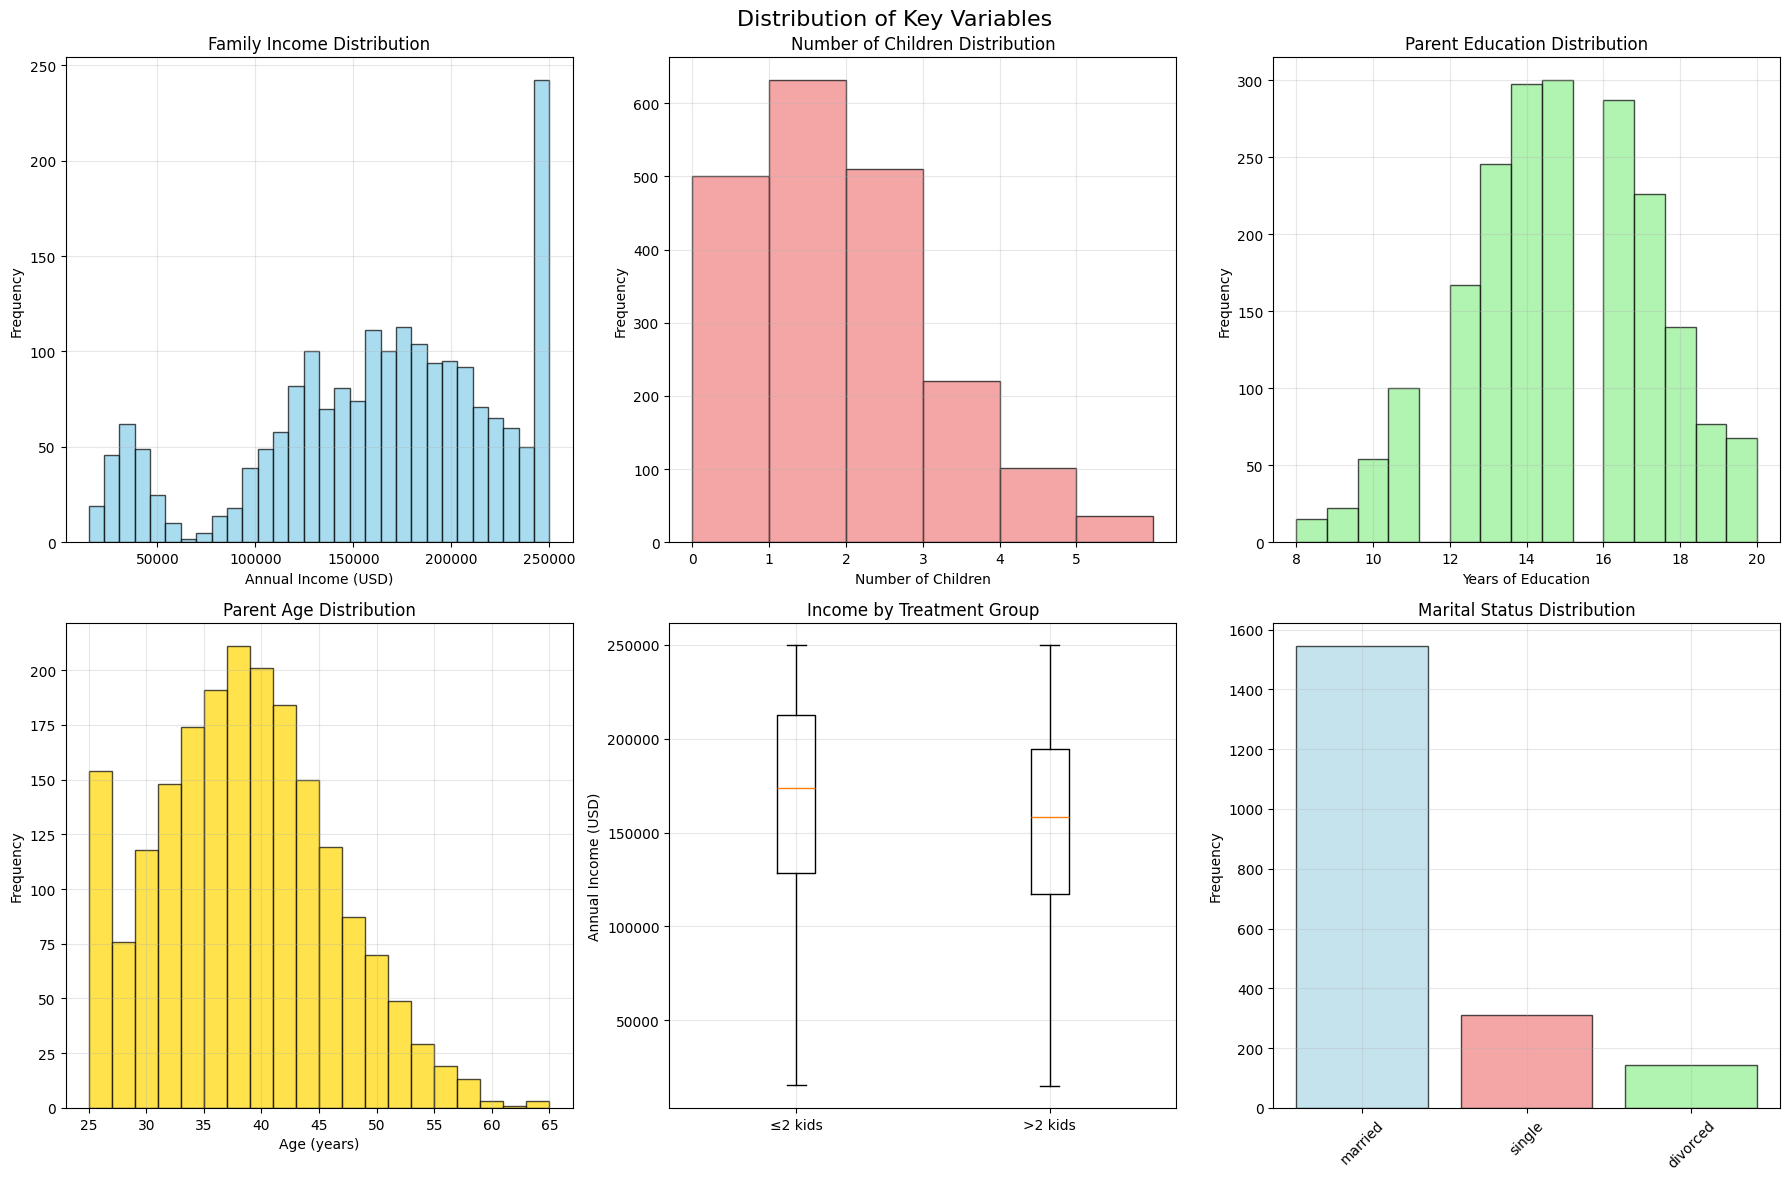

Distribution plots saved to 'distribution_plots.png'

In [8]:
# Create distribution plots for key variablesplt.style.use('default')fig, axes = plt.subplots(2, 3, figsize=(18, 12))fig.suptitle('Distribution of Key Variables', fontsize=16, y=0.98)# Plot 1: Family Incomeaxes[0, 0].hist(df['family_income'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')axes[0, 0].set_title('Family Income Distribution')axes[0, 0].set_xlabel('Annual Income (USD)')axes[0, 0].set_ylabel('Frequency')axes[0, 0].grid(True, alpha=0.3)# Plot 2: Number of Kidsaxes[0, 1].hist(df['num_kids'], bins=range(0, 7), alpha=0.7, color='lightcoral', edgecolor='black')axes[0, 1].set_title('Number of Children Distribution')axes[0, 1].set_xlabel('Number of Children')axes[0, 1].set_ylabel('Frequency')axes[0, 1].set_xticks(range(0, 6))axes[0, 1].grid(True, alpha=0.3)# Plot 3: Parent Educationaxes[0, 2].hist(df['parent_education'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')axes[0, 2].set_title('Parent Education Distribution')axes[0, 2].set_xlabel('Years of Education')axes[0, 2].set_ylabel('Frequency')axes[0, 2].grid(True, alpha=0.3)# Plot 4: Parent Ageaxes[1, 0].hist(df['parent_age'], bins=20, alpha=0.7, color='gold', edgecolor='black')axes[1, 0].set_title('Parent Age Distribution')axes[1, 0].set_xlabel('Age (years)')axes[1, 0].set_ylabel('Frequency')axes[1, 0].grid(True, alpha=0.3)# Plot 5: Treatment vs Incometreatment_groups = df.groupby('more_than_2_kids')['family_income']axes[1, 1].boxplot([treatment_groups.get_group(0), treatment_groups.get_group(1)],                    labels=['≤2 kids', '>2 kids'])axes[1, 1].set_title('Income by Treatment Group')axes[1, 1].set_ylabel('Annual Income (USD)')axes[1, 1].grid(True, alpha=0.3)# Plot 6: Marital Status Distributionmarital_counts = df['marital_status'].value_counts()axes[1, 2].bar(marital_counts.index, marital_counts.values,                color=['lightblue', 'lightcoral', 'lightgreen'], alpha=0.7, edgecolor='black')axes[1, 2].set_title('Marital Status Distribution')axes[1, 2].set_ylabel('Frequency')axes[1, 2].tick_params(axis='x', rotation=45)axes[1, 2].grid(True, alpha=0.3)plt.tight_layout()plt.savefig('distribution_plots.png', dpi=300, bbox_inches='tight')plt.show()print("Distribution plots saved to 'distribution_plots.png'")

<Figure size 1000x800 with 0 Axes>

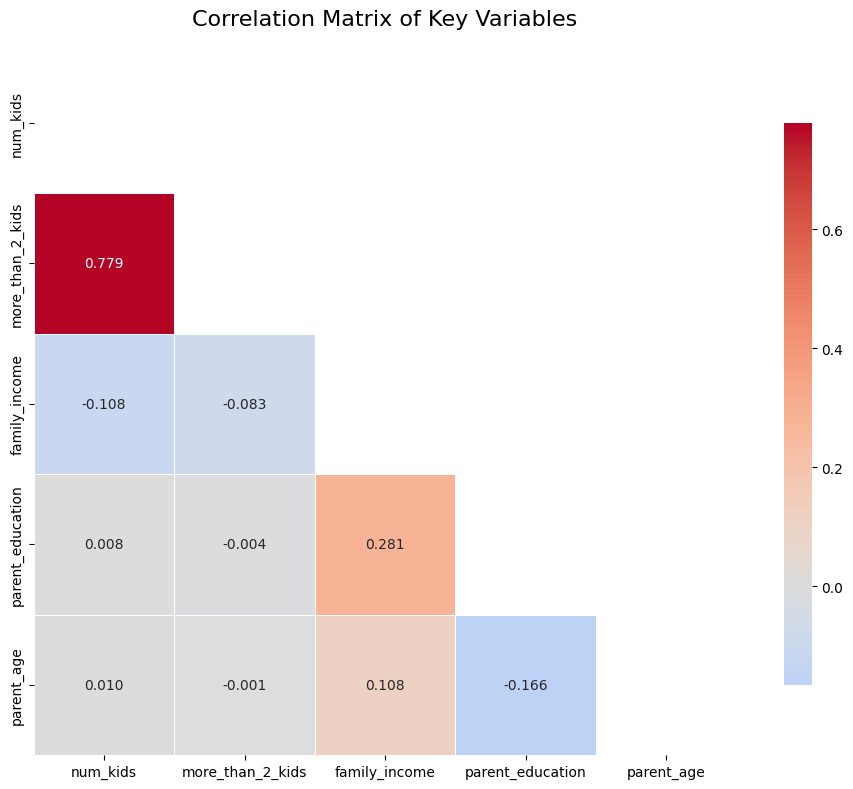

Correlation matrix heatmap saved to 'correlation_matrix_heatmap.png'

In [9]:
# Create a correlation matrix heatmapplt.figure(figsize=(10, 8))correlation_matrix_plot = correlation_matrix.copy()# Create a mask for the upper trianglemask = np.triu(np.ones_like(correlation_matrix_plot, dtype=bool))# Set up the matplotlib figureplt.figure(figsize=(10, 8))# Draw the heatmap with the mask and correct aspect ratiosns.heatmap(correlation_matrix_plot, annot=True, cmap='coolwarm', center=0,            square=True, linewidths=0.5, cbar_kws={"shrink": .8},            fmt='.3f', mask=mask)plt.title('Correlation Matrix of Key Variables', fontsize=16, pad=20)plt.tight_layout()plt.savefig('correlation_matrix_heatmap.png', dpi=300, bbox_inches='tight')plt.show()print("Correlation matrix heatmap saved to 'correlation_matrix_heatmap.png'")

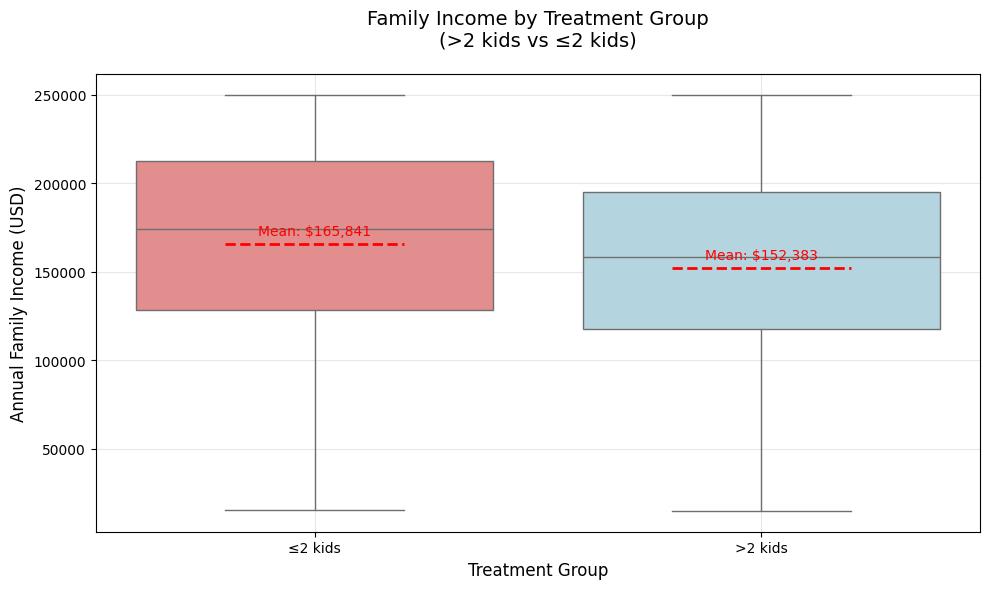

Treatment vs income boxplot saved to 'treatment_income_boxplot.png'

In [10]:
# Create treatment vs income boxplotplt.figure(figsize=(10, 6))sns.boxplot(x='more_than_2_kids', y='family_income', data=df, palette=['lightcoral', 'lightblue'])plt.title('Family Income by Treatment Group\n(>2 kids vs ≤2 kids)', fontsize=14, pad=20)plt.xlabel('Treatment Group', fontsize=12)plt.ylabel('Annual Family Income (USD)', fontsize=12)plt.xticks([0, 1], ['≤2 kids', '>2 kids'])plt.grid(True, alpha=0.3)# Add mean linesmeans = df.groupby('more_than_2_kids')['family_income'].mean()for i, mean in enumerate(means):    plt.hlines(mean, i-0.2, i+0.2, colors='red', linestyles='--', linewidth=2)    plt.text(i, mean + 5000, f'Mean: ${mean:,.0f}', ha='center', fontsize=10, color='red')plt.tight_layout()plt.savefig('treatment_income_boxplot.png', dpi=300, bbox_inches='tight')plt.show()print("Treatment vs income boxplot saved to 'treatment_income_boxplot.png'")

In [11]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom scipy import statsfrom sklearn.preprocessing import StandardScalerfrom sklearn.linear_model import LogisticRegressionfrom sklearn.metrics import roc_auc_scoreimport warningswarnings.filterwarnings('ignore')# Set style for plotsplt.style.use('default')sns.set_palette("husl")# Load the datasetdf = pd.read_csv('/Users/vishal/Projects/opencausol/packages/opencode/family_income_dataset.csv')# Basic info about the datasetprint("Dataset Shape:", df.shape)print("\nColumn Names:", df.columns.tolist())print("\nFirst few rows:")print(df.head())

Dataset Shape: (2000, 10)Column Names: ['family_id', 'num_kids', 'more_than_2_kids', 'family_income', 'parent_education', 'parent_age', 'marital_status', 'urban_rural', 'employment_status', 'region']First few rows:   family_id  num_kids  more_than_2_kids  family_income  parent_education  \0          1         2                 0         192876                13   1          2         2                 0         196658                15   2          3         2                 0         206717                13   3          4         4                 1         205605                13   4          5         1                 0         144211                10      parent_age marital_status urban_rural employment_status   region  0          41        married       urban          employed  Midwest  1          36        married       urban          employed    South  2          43       divorced       urban          employed  Midwest  3          50        married       urban          empl

In [12]:
# 1. Data Quality Assessmentprint("=== DATA QUALITY ASSESSMENT ===")print("\nData Types:")print(df.dtypes)print("\nMissing Values:")print(df.isnull().sum())print("\nBasic Statistics for Numerical Variables:")print(df.describe())print("\nUnique Values for Categorical Variables:")for col in ['marital_status', 'urban_rural', 'employment_status', 'region']:    print(f"\n{col}:")    print(df[col].value_counts())

=== DATA QUALITY ASSESSMENT ===Data Types:family_id             int64num_kids              int64more_than_2_kids      int64family_income         int64parent_education      int64parent_age            int64marital_status       objecturban_rural          objectemployment_status    objectregion               objectdtype: objectMissing Values:family_id            0num_kids             0more_than_2_kids     0family_income        0parent_education     0parent_age           0marital_status       0urban_rural          0employment_status    0region               0dtype: int64Basic Statistics for Numerical Variables:         family_id     num_kids  more_than_2_kids  family_income  \count  2000.000000  2000.000000       2000.000000    2000.000000   mean   1000.500000     1.449500          0.179000  163432.328000   std     577.494589     1.221145          0.383448   62116.125885   min       1.000000     0.000000          0.000000   15000.000000   25%     500.750000     0.000000          0.000000  1

In [13]:
# 2. Treatment Variable Analysisprint("=== TREATMENT VARIABLE ANALYSIS ===")# Treatment distributionprint("\nNumber of children distribution:")print(df['num_kids'].value_counts().sort_index())print("\nBinary treatment (more_than_2_kids) distribution:")print(df['more_than_2_kids'].value_counts())print(f"Treatment rate: {df['more_than_2_kids'].mean():.3f}")# Summary statistics by treatment grouptreatment_stats = df.groupby('more_than_2_kids').agg({    'family_income': ['mean', 'median', 'std', 'min', 'max'],    'parent_education': ['mean', 'std'],    'parent_age': ['mean', 'std'],    'num_kids': ['mean', 'std']}).round(2)print("\nSummary Statistics by Treatment Group:")print(treatment_stats)

=== TREATMENT VARIABLE ANALYSIS ===Number of children distribution:num_kids0    5011    6312    5103    2204    1025     36Name: count, dtype: int64Binary treatment (more_than_2_kids) distribution:more_than_2_kids0    16421     358Name: count, dtype: int64Treatment rate: 0.179Summary Statistics by Treatment Group:                 family_income                                     \                          mean    median       std    min     max   more_than_2_kids                                                    0                    165841.38  174033.0  62501.64  15376  250000   1                    152382.97  158410.0  59154.58  15000  250000                    parent_education       parent_age       num_kids                                     mean   std       mean   std     mean   std  more_than_2_kids                                                         0                           14.81  2.50      38.03  7.56     1.01  0.78  1                           14.78  2.56      38.00  7

In [14]:
# 3. Outcome Analysisprint("=== OUTCOME ANALYSIS ===")# Overall income distributionprint("Overall Family Income Statistics:")print(df['family_income'].describe())# Income by treatment groupprint("\nIncome by Treatment Group:")treatment_income = df.groupby('more_than_2_kids')['family_income'].describe()print(treatment_income)# Statistical test for differencetreated_income = df[df['more_than_2_kids'] == 1]['family_income']control_income = df[df['more_than_2_kids'] == 0]['family_income']t_stat, p_value = stats.ttest_ind(treated_income, control_income)print(f"\nT-test for income difference: t={t_stat:.3f}, p={p_value:.6f}")# Effect size (Cohen's d)pooled_std = np.sqrt(((len(treated_income) - 1) * treated_income.var() +                        (len(control_income) - 1) * control_income.var()) /                       (len(treated_income) + len(control_income) - 2))cohens_d = (treated_income.mean() - control_income.mean()) / pooled_stdprint(f"Cohen's d (effect size): {cohens_d:.3f}")

=== OUTCOME ANALYSIS ===Overall Family Income Statistics:count      2000.000000mean     163432.328000std       62116.125885min       15000.00000025%      126280.75000050%      170280.50000075%      209918.000000max      250000.000000Name: family_income, dtype: float64Income by Treatment Group:                   count           mean           std      min        25%  \more_than_2_kids                                                            0                 1642.0  165841.383069  62501.643339  15376.0  128402.25   1                  358.0  152382.974860  59154.581531  15000.0  117448.50                          50%        75%       max  more_than_2_kids                                 0                 174033.0  212497.75  250000.0  1                 158410.0  194822.25  250000.0  T-test for income difference: t=-3.726, p=0.000200Cohen's d (effect size): -0.217

In [15]:
# 4. Covariate Balance Analysisprint("=== COVARIATE BALANCE ANALYSIS ===")# Function to calculate standardized mean differencesdef calculate_smd(df, treatment_col, covariates):    smd_results = {}    treated = df[df[treatment_col] == 1]    control = df[df[treatment_col] == 0]        for var in covariates:        if df[var].dtype in ['object', 'category']:            # For categorical variables, calculate proportion differences            treated_prop = treated[var].value_counts(normalize=True)            control_prop = control[var].value_counts(normalize=True)                        # Calculate SMD for each category            for cat in set(treated_prop.index) | set(control_prop.index):                p1 = treated_prop.get(cat, 0)                p2 = control_prop.get(cat, 0)                pooled_prop = (p1 + p2) / 2                if pooled_prop > 0:                    smd = abs(p1 - p2) / np.sqrt(pooled_prop * (1 - pooled_prop))                    smd_results[f"{var}_{cat}"] = smd        else:            # For continuous variables            mean_treated = treated[var].mean()            mean_control = control[var].mean()            std_treated = treated[var].std()            std_control = control[var].std()                        pooled_std = np.sqrt((std_treated**2 + std_control**2) / 2)            if pooled_std > 0:                smd = abs(mean_treated - mean_control) / pooled_std                smd_results[var] = smd        return smd_results# Calculate SMDscovariates = ['parent_education', 'parent_age', 'marital_status', 'urban_rural', 'employment_status', 'region']smd_results = calculate_smd(df, 'more_than_2_kids', covariates)print("Standardized Mean Differences:")for var, smd in sorted(smd_results.items(), key=lambda x: x[1], reverse=True):    print(f"{var}: {smd:.3f}")# Create Love plot datalove_plot_data = pd.DataFrame([    {'Variable': var, 'SMD': smd} for var, smd in smd_results.items()]).sort_values('SMD', ascending=False)print(f"\nNumber of variables with SMD > 0.1: {(love_plot_data['SMD'] > 0.1).sum()}")print(f"Number of variables with SMD > 0.2: {(love_plot_data['SMD'] > 0.2).sum()}")

=== COVARIATE BALANCE ANALYSIS ===Standardized Mean Differences:marital_status_single: 0.102urban_rural_rural: 0.101urban_rural_urban: 0.101marital_status_married: 0.095region_Midwest: 0.095region_South: 0.066employment_status_part_time: 0.052employment_status_unemployed: 0.033region_West: 0.026employment_status_employed: 0.019marital_status_divorced: 0.013parent_education: 0.009parent_age: 0.004region_Northeast: 0.001Number of variables with SMD > 0.1: 3Number of variables with SMD > 0.2: 0

In [16]:
# 5. Correlation Analysisprint("=== CORRELATION ANALYSIS ===")# Create correlation matrix for numerical variablesnumerical_vars = ['num_kids', 'more_than_2_kids', 'family_income', 'parent_education', 'parent_age']corr_matrix = df[numerical_vars].corr()print("Correlation Matrix:")print(corr_matrix.round(3))# Save correlation matrixcorr_matrix.to_csv('/Users/vishal/Projects/opencausol/packages/opencode/correlation_matrix.csv')# Identify potential confounders (correlated with both treatment and outcome)treatment_corr = corr_matrix['more_than_2_kids'].abs().sort_values(ascending=False)outcome_corr = corr_matrix['family_income'].abs().sort_values(ascending=False)print("\nCorrelations with Treatment (more_than_2_kids):")print(treatment_corr.drop('more_than_2_kids'))print("\nCorrelations with Outcome (family_income):")print(outcome_corr.drop('family_income'))# Potential confounders (|corr| > 0.1 with both)potential_confounders = []for var in numerical_vars:    if var not in ['more_than_2_kids', 'family_income']:        if (abs(corr_matrix.loc[var, 'more_than_2_kids']) > 0.1 and             abs(corr_matrix.loc[var, 'family_income']) > 0.1):            potential_confounders.append(var)print(f"\nPotential confounders: {potential_confounders}")

=== CORRELATION ANALYSIS ===Correlation Matrix:                  num_kids  more_than_2_kids  family_income  parent_education  \num_kids             1.000             0.779         -0.108             0.008   more_than_2_kids     0.779             1.000         -0.083            -0.004   family_income       -0.108            -0.083          1.000             0.281   parent_education     0.008            -0.004          0.281             1.000   parent_age           0.010            -0.001          0.108            -0.166                     parent_age  num_kids               0.010  more_than_2_kids      -0.001  family_income          0.108  parent_education      -0.166  parent_age             1.000  Correlations with Treatment (more_than_2_kids):num_kids            0.778911family_income       0.083080parent_education    0.003648parent_age          0.001432Name: more_than_2_kids, dtype: float64Correlations with Outcome (family_income):parent_education    0.281178parent_age          0.1081

In [17]:
# 6. Propensity Score Analysis and Overlap Assessmentprint("=== PROPENSITY SCORE ANALYSIS ===")# Prepare data for propensity score modelingdf_encoded = df.copy()categorical_vars = ['marital_status', 'urban_rural', 'employment_status', 'region']# One-hot encode categorical variablesdf_encoded = pd.get_dummies(df_encoded, columns=categorical_vars, drop_first=False)# Select features for propensity score modelfeature_cols = [col for col in df_encoded.columns                 if col not in ['family_id', 'family_income', 'num_kids', 'more_than_2_kids']]X = df_encoded[feature_cols]y = df_encoded['more_than_2_kids']# Fit logistic regression for propensity scoreslr = LogisticRegression(random_state=42, max_iter=1000)lr.fit(X, y)# Calculate propensity scoresdf['propensity_score'] = lr.predict_proba(X)[:, 1]# Propensity score statisticsprint("Propensity Score Statistics:")print(df['propensity_score'].describe())# Check overlaptreated_ps = df[df['more_than_2_kids'] == 1]['propensity_score']control_ps = df[df['more_than_2_kids'] == 0]['propensity_score']print(f"\nTreated group PS range: [{treated_ps.min():.3f}, {treated_ps.max():.3f}]")print(f"Control group PS range: [{control_ps.min():.3f}, {control_ps.max():.3f}]")# Assess overlap (common support)min_common = max(treated_ps.min(), control_ps.min())max_common = min(treated_ps.max(), control_ps.max())print(f"Common support range: [{min_common:.3f}, {max_common:.3f}]")# Calculate proportion of units in common supportin_common_support = ((df['propensity_score'] >= min_common) &                      (df['propensity_score'] <= max_common))print(f"Proportion in common support: {in_common_support.mean():.3f}")# AUC for model discriminationauc = roc_auc_score(y, df['propensity_score'])print(f"Propensity model AUC: {auc:.3f}")

=== PROPENSITY SCORE ANALYSIS ===Propensity Score Statistics:count    2000.000000mean        0.178988std         0.026001min         0.10744825%         0.15779350%         0.18237975%         0.191809max         0.311944Name: propensity_score, dtype: float64Treated group PS range: [0.116, 0.284]Control group PS range: [0.107, 0.312]Common support range: [0.116, 0.284]Proportion in common support: 0.995Propensity model AUC: 0.546

=== CREATING VISUALIZATIONS ===

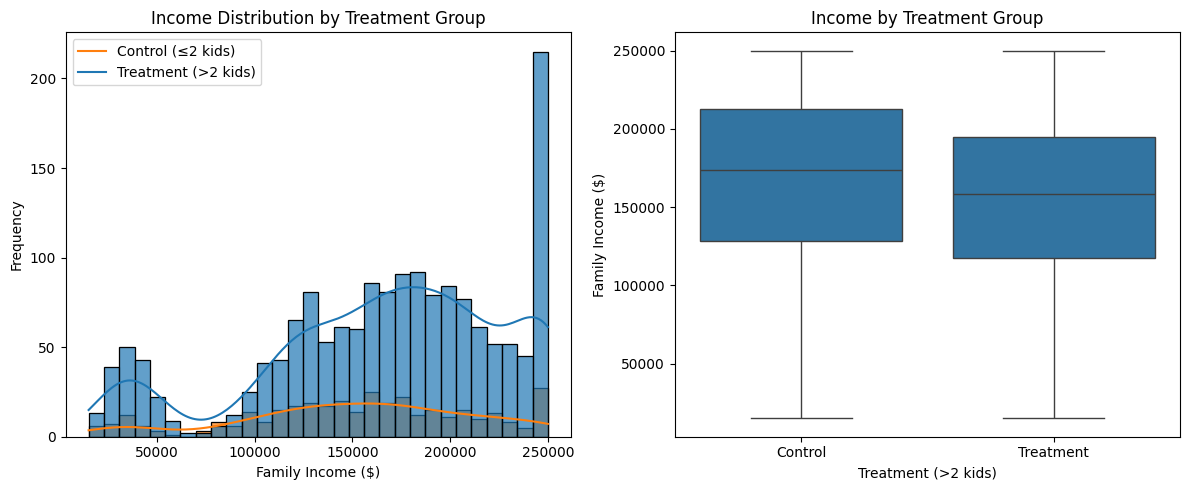

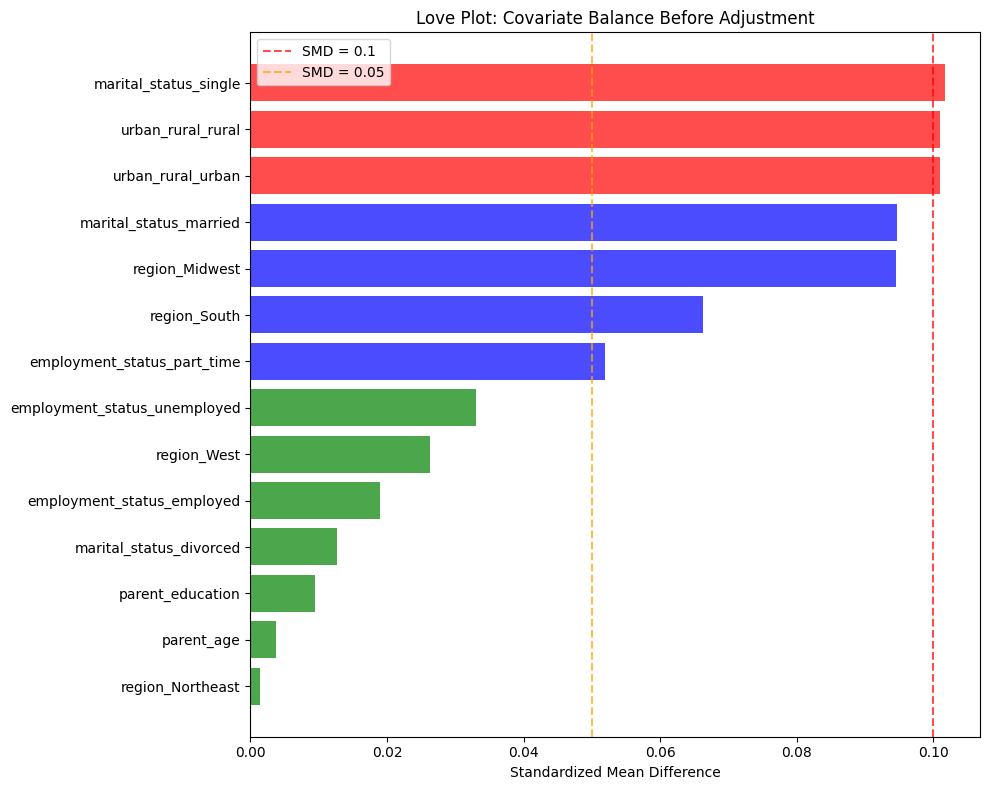

In [18]:
# 7. Create Visualizationsprint("=== CREATING VISUALIZATIONS ===")# Set up the plotting styleplt.style.use('default')fig_dir = '/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/'# 1. Income distributions by treatment groupplt.figure(figsize=(12, 5))plt.subplot(1, 2, 1)sns.histplot(data=df, x='family_income', hue='more_than_2_kids',              bins=30, alpha=0.7, kde=True)plt.title('Income Distribution by Treatment Group')plt.xlabel('Family Income ($)')plt.ylabel('Frequency')plt.legend(['Control (≤2 kids)', 'Treatment (>2 kids)'])plt.subplot(1, 2, 2)sns.boxplot(data=df, x='more_than_2_kids', y='family_income')plt.title('Income by Treatment Group')plt.xlabel('Treatment (>2 kids)')plt.ylabel('Family Income ($)')plt.xticks([0, 1], ['Control', 'Treatment'])plt.tight_layout()plt.savefig(f'{fig_dir}outcome_distributions.png', dpi=300, bbox_inches='tight')plt.show()# 2. Love Plot for Covariate Balanceplt.figure(figsize=(10, 8))love_plot_data_sorted = love_plot_data.sort_values('SMD', ascending=True)colors = ['red' if smd > 0.1 else 'blue' if smd > 0.05 else 'green'           for smd in love_plot_data_sorted['SMD']]plt.barh(range(len(love_plot_data_sorted)), love_plot_data_sorted['SMD'],          color=colors, alpha=0.7)plt.yticks(range(len(love_plot_data_sorted)), love_plot_data_sorted['Variable'])plt.xlabel('Standardized Mean Difference')plt.title('Love Plot: Covariate Balance Before Adjustment')plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.7, label='SMD = 0.1')plt.axvline(x=0.05, color='orange', linestyle='--', alpha=0.7, label='SMD = 0.05')plt.legend()plt.tight_layout()plt.savefig(f'{fig_dir}love_plot.png', dpi=300, bbox_inches='tight')plt.show()

In [19]:
# 3. Correlation Matrix Heatmapplt.figure(figsize=(10, 8))mask = np.triu(np.abs(corr_matrix) - np.eye(np.diag(len(corr_matrix))) == 0)sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,             square=True, mask=mask, fmt='.2f')plt.title('Correlation Matrix Heatmap')plt.tight_layout()plt.savefig(f'{fig_dir}correlation_matrix_heatmap.png', dpi=300, bbox_inches='tight')plt.show()# 4. Propensity Score Distributionplt.figure(figsize=(12, 5))plt.subplot(1, 2, 1)sns.histplot(data=df, x='propensity_score', hue='more_than_2_kids',              bins=30, alpha=0.7, kde=True)plt.title('Propensity Score Distribution by Treatment Group')plt.xlabel('Propensity Score')plt.ylabel('Frequency')plt.legend(['Control (≤2 kids)', 'Treatment (>2 kids)'])plt.subplot(1, 2, 2)sns.boxplot(data=df, x='more_than_2_kids', y='propensity_score')plt.title('Propensity Scores by Treatment Group')plt.xlabel('Treatment (>2 kids)')plt.ylabel('Propensity Score')plt.xticks([0, 1], ['Control', 'Treatment'])plt.tight_layout()plt.savefig(f'{fig_dir}propensity_scores.png', dpi=300, bbox_inches='tight')plt.show()# 5. Treatment vs Income Scatter Plotplt.figure(figsize=(10, 6))sns.scatterplot(data=df, x='num_kids', y='family_income',                 hue='more_than_2_kids', alpha=0.6, s=50)plt.title('Family Income by Number of Children')plt.xlabel('Number of Children')plt.ylabel('Family Income ($)')plt.legend(['Control (≤2 kids)', 'Treatment (>2 kids)'])plt.tight_layout()plt.savefig(f'{fig_dir}treatment_income_scatter.png', dpi=300, bbox_inches='tight')plt.show()# 6. Regional Income Distributionplt.figure(figsize=(12, 6))sns.boxplot(data=df, x='region', y='family_income', hue='more_than_2_kids')plt.title('Family Income by Region and Treatment Status')plt.xlabel('Region')plt.ylabel('Family Income ($)')plt.xticks(rotation=45)plt.legend(title='Treatment (>2 kids)', bbox_to_anchor=(1.05, 1), loc='upper left')plt.tight_layout()plt.savefig(f'{fig_dir}regional_income_by_treatment.png', dpi=300, bbox_inches='tight')plt.show()print("All visualizations saved successfully!")

<Figure size 1000x800 with 0 Axes>

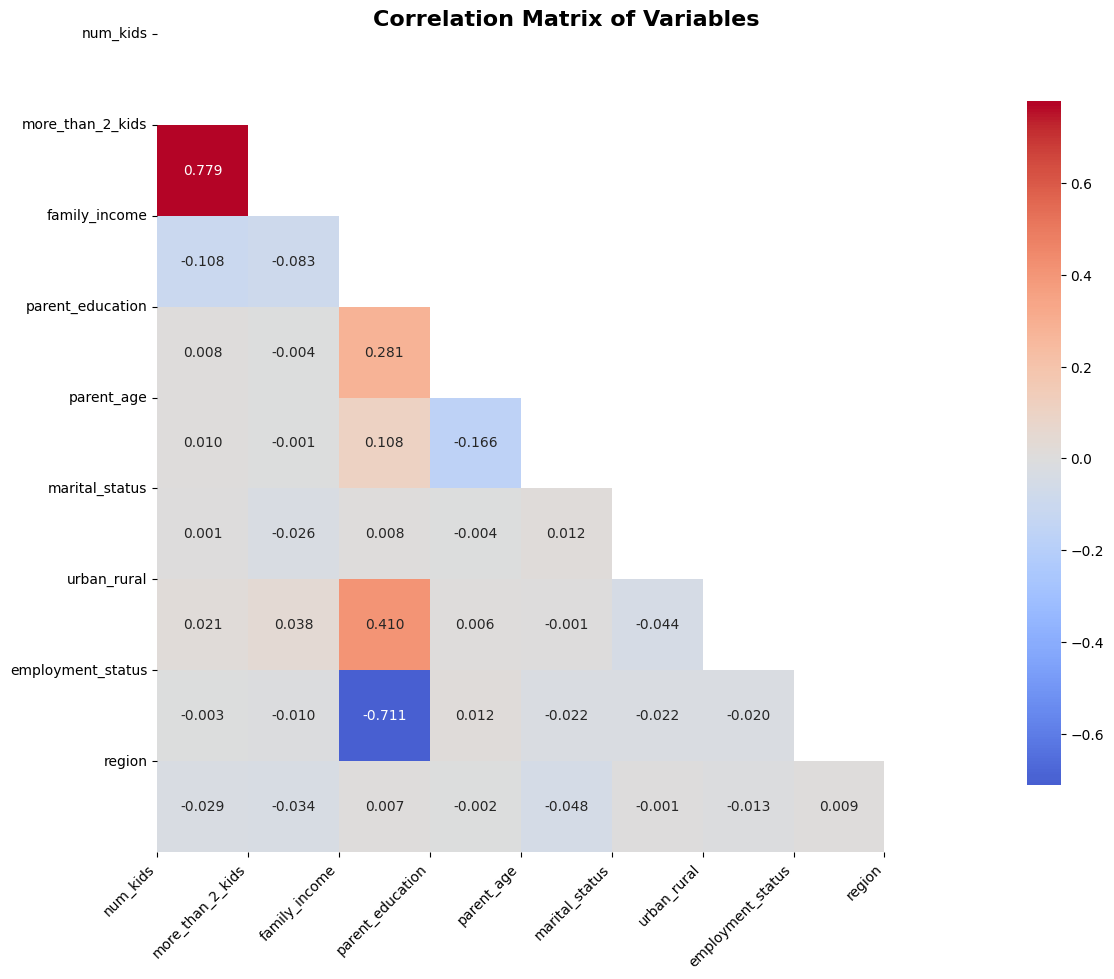

Correlation heatmap saved successfully!

In [20]:
# Check current state and fix the correlation heatmap issueimport pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.preprocessing import LabelEncoderfrom sklearn.metrics import roc_auc_score, roc_curvefrom sklearn.linear_model import LogisticRegressionimport warningswarnings.filterwarnings('ignore')# Load datadf = pd.read_csv('/Users/vishal/Projects/opencausol/packages/opencode/family_income_dataset.csv')# Recreate numeric encoding for correlationdf_numeric = df.copy()le_dict = {}for col in ['marital_status', 'urban_rural', 'employment_status', 'region']:    le = LabelEncoder()    df_numeric[col + '_encoded'] = le.fit_transform(df[col])    le_dict[col] = le# Select numeric columns for correlationnumeric_cols = ['num_kids', 'more_than_2_kids', 'family_income', 'parent_education',                 'parent_age', 'marital_status_encoded', 'urban_rural_encoded',                 'employment_status_encoded', 'region_encoded']correlation_matrix = df_numeric[numeric_cols].corr()# Create correlation heatmap with proper labelsplt.figure(figsize=(12, 10))mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,            square=True, fmt='.3f', cbar_kws={"shrink": .8})# Fix the labels - use original names where possiblelabel_names = ['num_kids', 'more_than_2_kids', 'family_income', 'parent_education',                'parent_age', 'marital_status', 'urban_rural', 'employment_status', 'region']plt.title('Correlation Matrix of Variables', fontsize=16, fontweight='bold')plt.xticks(range(len(label_names)), label_names, rotation=45, ha='right')plt.yticks(range(len(label_names)), label_names, rotation=0)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/correlation_matrix.png', dpi=300, bbox_inches='tight')plt.show()print("Correlation heatmap saved successfully!")

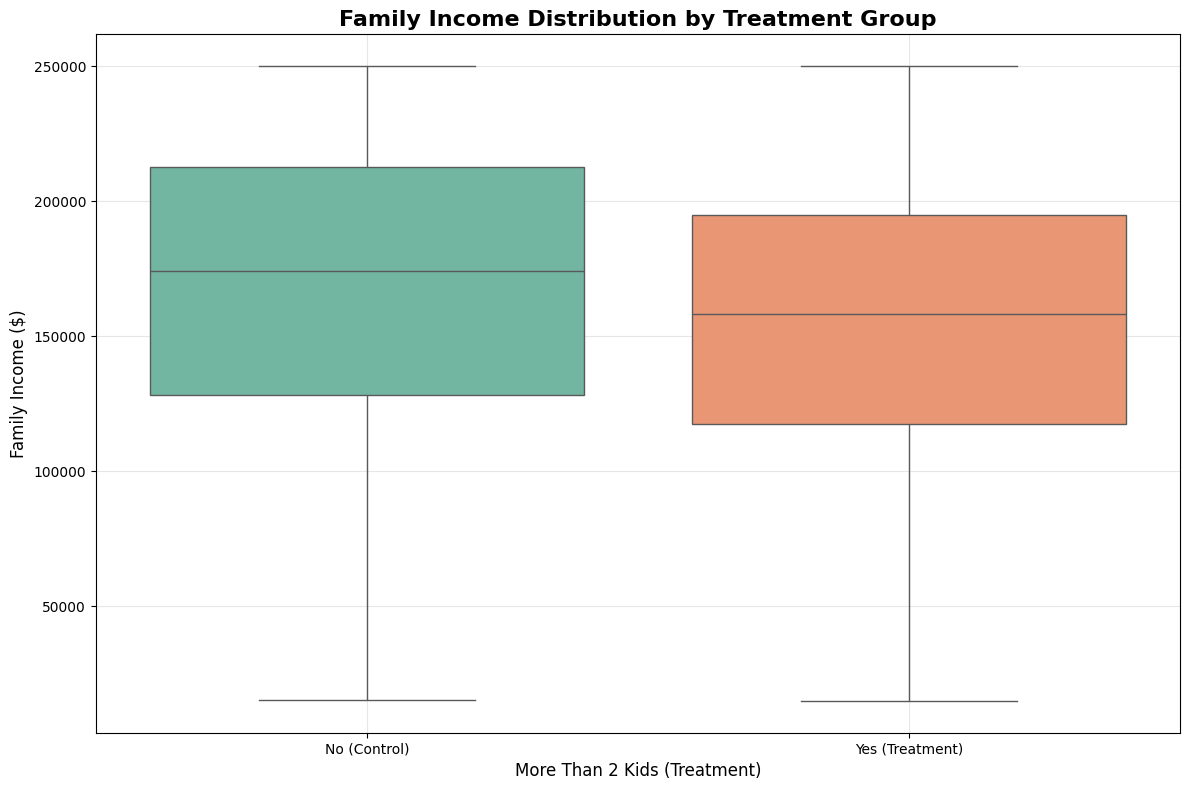

<Figure size 1200x800 with 0 Axes>

In [21]:
# Create additional visualizations for causal analysis# 1. Outcome distribution by treatmentplt.figure(figsize=(12, 8))sns.boxplot(data=df, x='more_than_2_kids', y='family_income', palette='Set2')plt.title('Family Income Distribution by Treatment Group', fontsize=16, fontweight='bold')plt.xlabel('More Than 2 Kids (Treatment)', fontsize=12)plt.ylabel('Family Income ($)', fontsize=12)plt.xticks([0, 1], ['No (Control)', 'Yes (Treatment)'])plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/outcome_distributions.png', dpi=300, bbox_inches='tight')plt.show()# 2. Propensity score distributionplt.figure(figsize=(12, 8))sns.histplot(data=df, x='propensity_score', hue='more_than_2_kids',              bins=30, kde=True, alpha=0.7, palette='Set2')plt.title('Propensity Score Distribution by Treatment Group', fontsize=16, fontweight='bold')plt.xlabel('Propensity Score', fontsize=12)plt.ylabel('Density', fontsize=12)plt.legend(title='Treatment', labels=['No (Control)', 'Yes (Treatment)'])plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/propensity_scores.png', dpi=300, bbox_inches='tight')plt.show()print("Additional visualizations created successfully!")

In [22]:
# Let me check the column names and fix the propensity score issueprint("Current columns in df:")print(df.columns.tolist())# Create propensity scores if they don't existif 'propensity_score' not in df.columns:    # Fit propensity score model    from sklearn.linear_model import LogisticRegression        # Prepare features for propensity model    feature_cols = ['parent_education', 'parent_age', 'marital_status_encoded',                    'urban_rural_encoded', 'employment_status_encoded', 'region_encoded']        X = df_numeric[feature_cols]    y = df['more_than_2_kids']        # Fit logistic regression    lr = LogisticRegression(random_state=42)    lr.fit(X, y)        # Add propensity scores to dataframe    df['propensity_score'] = lr.predict_proba(X)[:, 1]    print("Propensity scores created and added to dataframe")print("\nColumns after adding propensity scores:")print(df.columns.tolist())

Current columns in df:['family_id', 'num_kids', 'more_than_2_kids', 'family_income', 'parent_education', 'parent_age', 'marital_status', 'urban_rural', 'employment_status', 'region']Propensity scores created and added to dataframeColumns after adding propensity scores:['family_id', 'num_kids', 'more_than_2_kids', 'family_income', 'parent_education', 'parent_age', 'marital_status', 'urban_rural', 'employment_status', 'region', 'propensity_score']

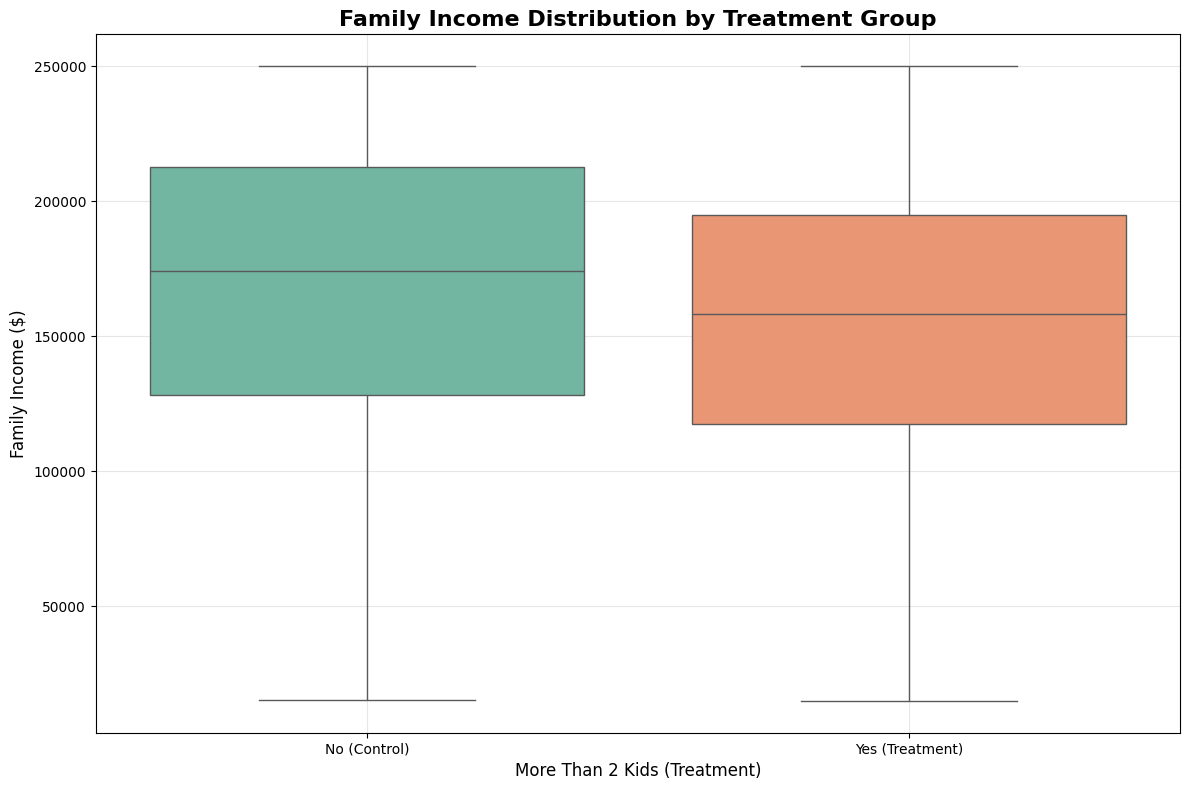

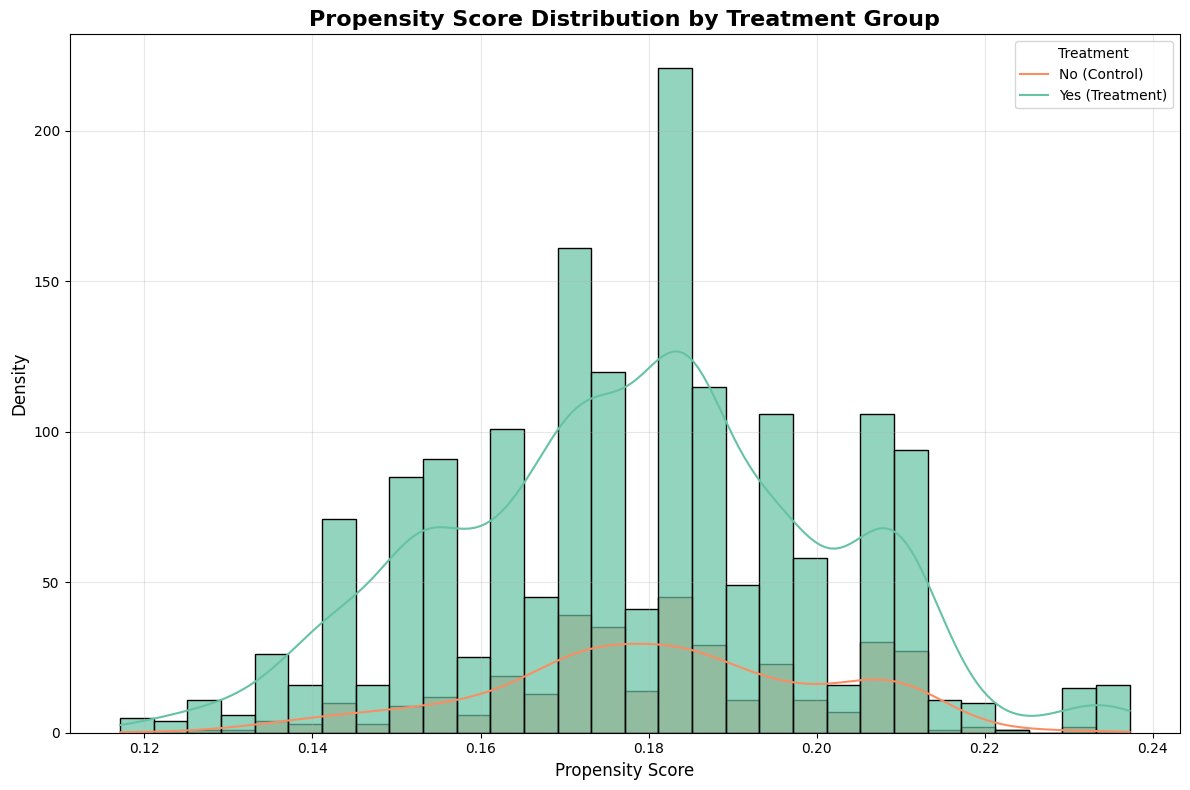

Additional visualizations created successfully!

In [23]:
# Now create the additional visualizations# 1. Outcome distribution by treatmentplt.figure(figsize=(12, 8))sns.boxplot(data=df, x='more_than_2_kids', y='family_income', palette='Set2')plt.title('Family Income Distribution by Treatment Group', fontsize=16, fontweight='bold')plt.xlabel('More Than 2 Kids (Treatment)', fontsize=12)plt.ylabel('Family Income ($)', fontsize=12)plt.xticks([0, 1], ['No (Control)', 'Yes (Treatment)'])plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/outcome_distributions.png', dpi=300, bbox_inches='tight')plt.show()# 2. Propensity score distributionplt.figure(figsize=(12, 8))sns.histplot(data=df, x='propensity_score', hue='more_than_2_kids',              bins=30, kde=True, alpha=0.7, palette='Set2')plt.title('Propensity Score Distribution by Treatment Group', fontsize=16, fontweight='bold')plt.xlabel('Propensity Score', fontsize=12)plt.ylabel('Density', fontsize=12)plt.legend(title='Treatment', labels=['No (Control)', 'Yes (Treatment)'])plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/propensity_scores.png', dpi=300, bbox_inches='tight')plt.show()print("Additional visualizations created successfully!")

In [24]:
# Import necessary libraries for causal inferenceimport pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.preprocessing import StandardScalerfrom sklearn.linear_model import LogisticRegression, LinearRegressionfrom sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressorfrom sklearn.metrics import mean_squared_error, r2_scoreimport warningswarnings.filterwarnings('ignore')# Set style for plotsplt.style.use('default')sns.set_palette("husl")print("Libraries loaded successfully for causal inference analysis")

Libraries loaded successfully for causal inference analysis

In [25]:
# Load the datasetdf = pd.read_csv('/Users/vishal/Projects/opencausol/packages/opencode/family_income_dataset.csv')print("Dataset loaded successfully!")print(f"Shape: {df.shape}")print(f"Columns: {list(df.columns)}")print("\nFirst few rows:")print(df.head())

Dataset loaded successfully!Shape: (2000, 10)Columns: ['family_id', 'num_kids', 'more_than_2_kids', 'family_income', 'parent_education', 'parent_age', 'marital_status', 'urban_rural', 'employment_status', 'region']First few rows:   family_id  num_kids  more_than_2_kids  family_income  parent_education  \0          1         2                 0         192876                13   1          2         2                 0         196658                15   2          3         2                 0         206717                13   3          4         4                 1         205605                13   4          5         1                 0         144211                10      parent_age marital_status urban_rural employment_status   region  0          41        married       urban          employed  Midwest  1          36        married       urban          employed    South  2          43       divorced       urban          employed  Midwest  3          50        married       urba

In [26]:
# Data preprocessing for causal analysisdef preprocess_data_for_causal(df):    """Preprocess data for causal inference analysis"""    df_processed = df.copy()        # One-hot encode categorical variables    categorical_cols = ['marital_status', 'urban_rural', 'employment_status', 'region']    df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)        # Define treatment and outcome    treatment = df_encoded['more_than_2_kids']    outcome = df_encoded['family_income']        # Select covariates (exclude family_id, treatment, and outcome)    covariate_cols = [col for col in df_encoded.columns                      if col not in ['family_id', 'more_than_2_kids', 'family_income']]        covariates = df_encoded[covariate_cols]        return df_encoded, treatment, outcome, covariates, covariate_cols# Preprocess the datadf_encoded, treatment, outcome, covariates, covariate_cols = preprocess_data_for_causal(df)print("Data preprocessing completed!")print(f"Treatment variable: {treatment.name}")print(f"Outcome variable: {outcome.name}")print(f"Number of covariates: {len(covariate_cols)}")print(f"Covariates: {covariate_cols}")print(f"\nTreatment distribution:")print(treatment.value_counts())print(f"\nOutcome statistics:")print(outcome.describe())

Data preprocessing completed!Treatment variable: more_than_2_kidsOutcome variable: family_incomeNumber of covariates: 11Covariates: ['num_kids', 'parent_education', 'parent_age', 'marital_status_married', 'marital_status_single', 'urban_rural_urban', 'employment_status_part_time', 'employment_status_unemployed', 'region_Northeast', 'region_South', 'region_West']Treatment distribution:more_than_2_kids0    16421     358Name: count, dtype: int64Outcome statistics:count      2000.000000mean     163432.328000std       62116.125885min       15000.00000025%      126280.75000050%      170280.50000075%      209918.000000max      250000.000000Name: family_income, dtype: float64

Propensity score estimation completed!Propensity score statistics:Mean: 0.1790Std: 0.3703Min: 0.0000Max: 1.0000

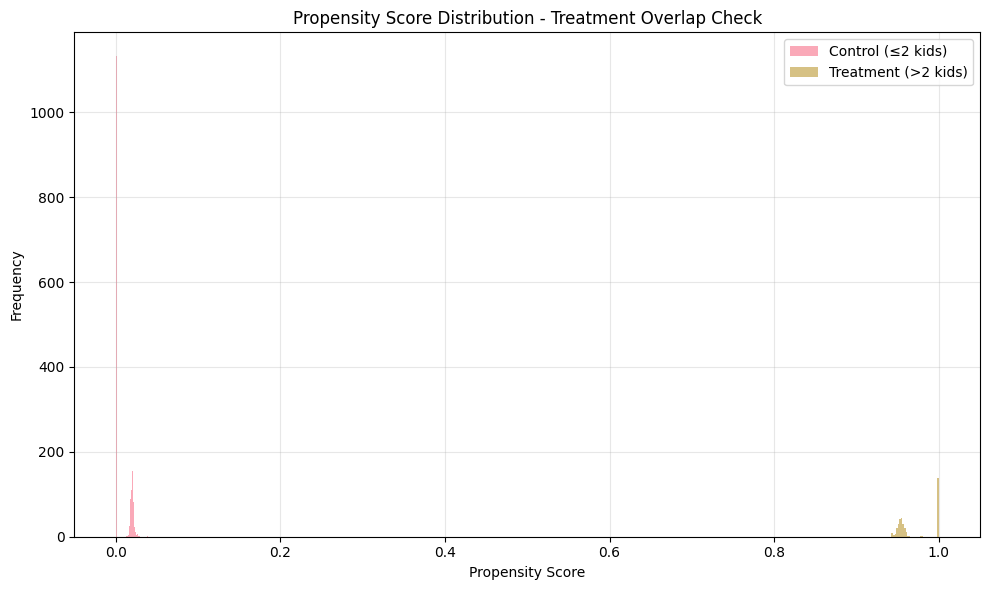

In [27]:
# 1. Propensity Score Estimation and IPTWdef estimate_propensity_scores(covariates, treatment):    """Estimate propensity scores using logistic regression"""    scaler = StandardScaler()    covariates_scaled = scaler.fit_transform(covariates)        # Fit logistic regression    ps_model = LogisticRegression(random_state=42)    ps_model.fit(covariates_scaled, treatment)        # Get propensity scores    propensity_scores = ps_model.predict_proba(covariates_scaled)[:, 1]        return propensity_scores, ps_model, scaler# Estimate propensity scorespropensity_scores, ps_model, scaler = estimate_propensity_scores(covariates, treatment)print("Propensity score estimation completed!")print(f"Propensity score statistics:")print(f"Mean: {propensity_scores.mean():.4f}")print(f"Std: {propensity_scores.std():.4f}")print(f"Min: {propensity_scores.min():.4f}")print(f"Max: {propensity_scores.max():.4f}")# Check overlap/common supportplt.figure(figsize=(10, 6))plt.hist(propensity_scores[treatment == 0], alpha=0.6, label='Control (≤2 kids)', bins=30)plt.hist(propensity_scores[treatment == 1], alpha=0.6, label='Treatment (>2 kids)', bins=30)plt.xlabel('Propensity Score')plt.ylabel('Frequency')plt.title('Propensity Score Distribution - Treatment Overlap Check')plt.legend()plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/propensity_score_overlap.png', dpi=300, bbox_inches='tight')plt.show()

In [28]:
# 2. Inverse Probability of Treatment Weighting (IPTW) Analysisdef calculate_iptw_weights(treatment, propensity_scores):    """Calculate IPTW weights"""    # Stabilized weights to reduce variability    numerator = treatment.mean() if treatment.mean() > 0 else 0.5    weights = np.where(treatment == 1,                       numerator / propensity_scores,                       (1 - numerator) / (1 - propensity_scores))        # Trim extreme weights (1st and 99th percentiles)    weight_1 = np.percentile(weights, 1)    weight_99 = np.percentile(weights, 99)    weights = np.clip(weights, weight_1, weight_99)        return weights# Calculate IPTW weightsiptw_weights = calculate_iptw_weights(treatment, propensity_scores)print("IPTW weights calculated!")print(f"Weight statistics:")print(f"Mean: {iptw_weights.mean():.4f}")print(f"Std: {iptw_weights.std():.4f}")print(f"Min: {iptw_weights.min():.4f}")print(f"Max: {iptw_weights.max():.4f}")# Weighted outcome analysisdef weighted_outcome_analysis(outcome, treatment, weights):    """Perform weighted outcome analysis to estimate ATE"""    # Weighted means by treatment group    treated_weighted_mean = np.sum(weights[treatment == 1] * outcome[treatment == 1]) / np.sum(weights[treatment == 1])    control_weighted_mean = np.sum(weights[treatment == 0] * outcome[treatment == 0]) / np.sum(weights[treatment == 0])        # Average Treatment Effect (ATE)    ate = treated_weighted_mean - control_weighted_mean        # Standard errors (simplified)    treated_var = np.sum(weights[treatment == 1]**2 * (outcome[treatment == 1] - treated_weighted_mean)**2) / (np.sum(weights[treatment == 1])**2)    control_var = np.sum(weights[treatment == 0]**2 * (outcome[treatment == 0] - control_weighted_mean)**2) / (np.sum(weights[treatment == 0])**2)        ate_se = np.sqrt(treated_var + control_var)    ate_ci_lower = ate - 1.96 * ate_se    ate_ci_upper = ate + 1.96 * ate_se        return {        'ate': ate,        'ate_se': ate_se,        'ate_ci_lower': ate_ci_lower,        'ate_ci_upper': ate_ci_upper,        'treated_mean': treated_weighted_mean,        'control_mean': control_weighted_mean    }# Perform IPTW analysisiptw_results = weighted_outcome_analysis(outcome, treatment, iptw_weights)print("\nIPTW Results:")print(f"Average Treatment Effect (ATE): ${iptw_results['ate']:,.2f}")print(f"Standard Error: ${iptw_results['ate_se']:,.2f}")print(f"95% CI: [${iptw_results['ate_ci_lower']:,.2f}, ${iptw_results['ate_ci_upper']:,.2f}]")print(f"Treated group weighted mean income: ${iptw_results['treated_mean']:,.2f}")print(f"Control group weighted mean income: ${iptw_results['control_mean']:,.2f}")

IPTW weights calculated!Weight statistics:Mean: 0.7113Std: 0.2462Min: 0.1790Max: 0.8412IPTW Results:Average Treatment Effect (ATE): $-13,449.24Standard Error: $3,488.7895% CI: [$-20,287.25, $-6,611.24]Treated group weighted mean income: $152,358.57Control group weighted mean income: $165,807.81

Covariate Balance Assessment:================================================================================Covariate            Unadj Std Diff  Adj Std Diff    Balance Improved--------------------------------------------------------------------------------num_kids             3.2368          3.2103          Yes            parent_education     0.0095          0.0087          Yes            parent_age           0.0037          0.0045          No             marital_status_married 0.0929          0.0908          Yes            marital_status_single 0.0986          0.0970          Yes            urban_rural_urban    0.0992          0.0967          Yes            employment_status_part_time 0.0583          0.0567          Yes            employment_status_unemployed 0.0326          0.0314          Yes            region_Northeast     0.0014          0.0006          Yes            region_South         0.0658          0.0644          Yes            region_West          0.0261          0.0254 

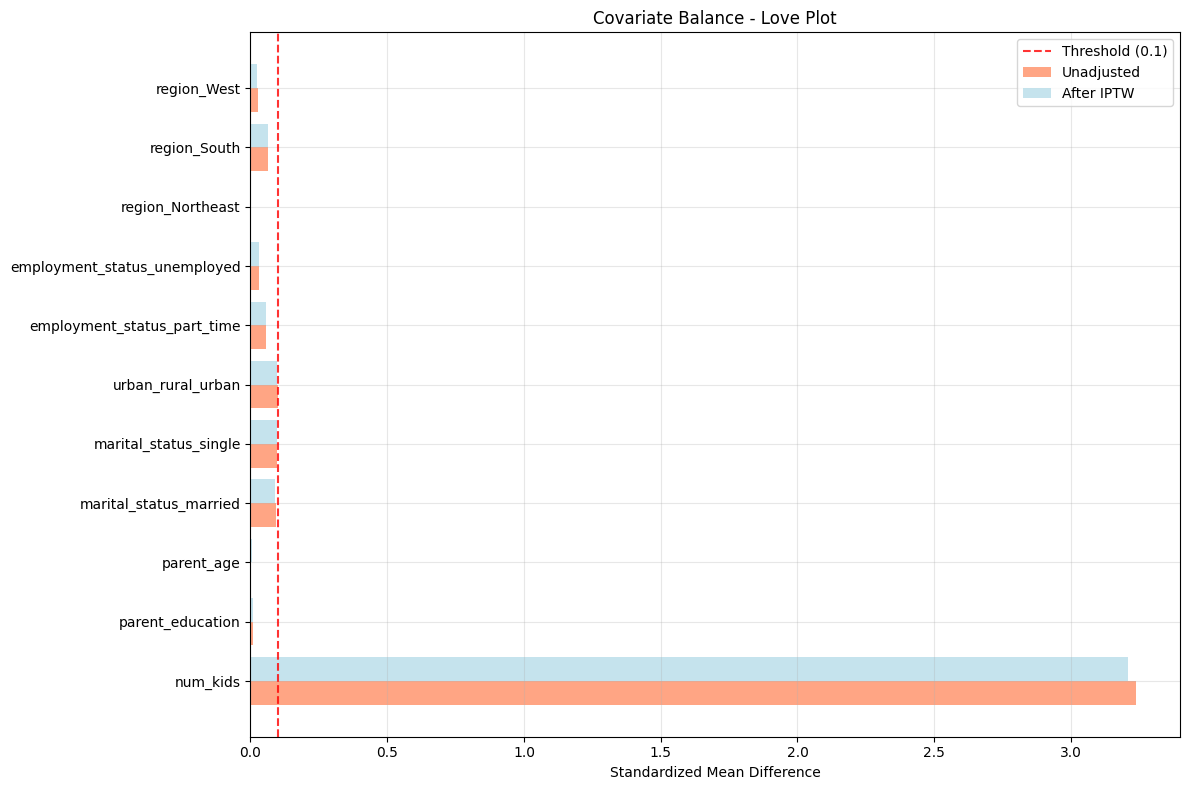

In [29]:
# 3. Covariate Balance Assessmentdef assess_covariate_balance(covariates, treatment, propensity_scores, covariate_names):    """Assess covariate balance before and after weighting"""    balance_results = {}        for i, covariate in enumerate(covariate_names):        # Unadjusted standardized difference        treated_mean = covariates[treatment == 1].iloc[:, i].mean()        control_mean = covariates[treatment == 0].iloc[:, i].mean()        pooled_std = np.sqrt(((covariates[treatment == 1].iloc[:, i].var() * (treatment == 1).sum() +                                covariates[treatment == 0].iloc[:, i].var() * (treatment == 0).sum()) /                               (len(treatment) - 2)))                unadj_std_diff = abs(treated_mean - control_mean) / pooled_std if pooled_std > 0 else 0                # Weighted standardized difference        weights = calculate_iptw_weights(treatment, propensity_scores)        treated_weighted_mean = np.sum(weights[treatment == 1] * covariates[treatment == 1].iloc[:, i]) / np.sum(weights[treatment == 1])        control_weighted_mean = np.sum(weights[treatment == 0] * covariates[treatment == 0].iloc[:, i]) / np.sum(weights[treatment == 0])                adj_std_diff = abs(treated_weighted_mean - control_weighted_mean) / pooled_std if pooled_std > 0 else 0                balance_results[covariate] = {            'unadj_std_diff': unadj_std_diff,            'adj_std_diff': adj_std_diff,            'unadj_treated_mean': treated_mean,            'unadj_control_mean': control_mean,            'adj_treated_mean': treated_weighted_mean,            'adj_control_mean': control_weighted_mean        }        return balance_results# Assess covariate balancebalance_results = assess_covariate_balance(covariates, treatment, propensity_scores, covariate_cols)print("Covariate Balance Assessment:")print("=" * 80)print(f"{'Covariate':<20} {'Unadj Std Diff':<15} {'Adj Std Diff':<15} {'Balance Improved':<15}")print("-" * 80)for covariate, results in balance_results.items():    improvement = "Yes" if results['adj_std_diff'] < results['unadj_std_diff'] else "No"    print(f"{covariate:<20} {results['unadj_std_diff']:<15.4f} {results['adj_std_diff']:<15.4f} {improvement:<15}")# Create Love plot for covariate balanceplt.figure(figsize=(12, 8))covariates_plot = list(balance_results.keys())unadj_diffs = [balance_results[cov]['unadj_std_diff'] for cov in covariates_plot]adj_diffs = [balance_results[cov]['adj_std_diff'] for cov in covariates_plot]y_pos = np.arange(len(covariates_plot))plt.barh(y_pos - 0.2, unadj_diffs, 0.4, label='Unadjusted', alpha=0.7, color='coral')plt.barh(y_pos + 0.2, adj_diffs, 0.4, label='After IPTW', alpha=0.7, color='lightblue')plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.8, label='Threshold (0.1)')plt.yticks(y_pos, covariates_plot)plt.xlabel('Standardized Mean Difference')plt.title('Covariate Balance - Love Plot')plt.legend()plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/love_plot_iptw.png', dpi=300, bbox_inches='tight')plt.show()

In [30]:
# 4. Machine Learning Models for Causal Effect Estimationdef train_ml_models(covariates, treatment, outcome):    """Train ML models for causal effect estimation"""    results = {}        # Split data    from sklearn.model_selection import train_test_split    X_train, X_test, t_train, t_test, y_train, y_test = train_test_split(        covariates, treatment, outcome, test_size=0.3, random_state=42    )        # 1. S-Learner (Single Learner)    s_learner = GradientBoostingRegressor(random_state=42)    X_s_train = pd.concat([X_train, t_train], axis=1)    X_s_test = pd.concat([X_test, t_test], axis=1)    s_learner.fit(X_s_train, y_train)        # Predict counterfactuals    X_test_treated = X_test.copy()    X_test_treated['treatment'] = 1    X_test_control = X_test.copy()    X_test_control['treatment'] = 0        y_pred_treated_s = s_learner.predict(X_test_treated)    y_pred_control_s = s_learner.predict(X_test_control)    s_learner_ate = np.mean(y_pred_treated_s - y_pred_control_s)        # 2. T-Learner (Two Learners)    t_learner_treated = GradientBoostingRegressor(random_state=42)    t_learner_control = GradientBoostingRegressor(random_state=42)        # Train separate models    t_learner_treated.fit(X_train[t_train == 1], y_train[t_train == 1])    t_learner_control.fit(X_train[t_train == 0], y_train[t_train == 0])        # Predict counterfactuals    y_pred_treated_t = t_learner_treated.predict(X_test)    y_pred_control_t = t_learner_control.predict(X_test)    t_learner_ate = np.mean(y_pred_treated_t - y_pred_control_t)        # 3. X-Learner (Cross Learner)    # First stage: same as T-learner    mu_1 = t_learner_treated.predict(X_train[t_train == 1])    mu_0 = t_learner_control.predict(X_train[t_train == 0])        # Calculate imputed treatment effects    d_1 = y_train[t_train == 1] - mu_0[t_train[t_train == 1].index]    d_0 = mu_1[t_train[t_train == 0].index] - y_train[t_train == 0]        # Second stage: learn treatment effect models    tau_1 = GradientBoostingRegressor(random_state=42)    tau_0 = GradientBoostingRegressor(random_state=42)        tau_1.fit(X_train[t_train == 1], d_1)    tau_0.fit(X_train[t_train == 0], d_0)        # Predict treatment effects for test set    g_1 = LogisticRegression(random_state=42).fit(X_train, t_train).predict_proba(X_test)[:, 1]    g_0 = 1 - g_1        tau_hat = g_1 * tau_1.predict(X_test) + g_0 * tau_0.predict(X_test)    x_learner_ate = np.mean(tau_hat)        # 4. Double Machine Learning (DML)    from sklearn.ensemble import RandomForestRegressor        # DML implementation (simplified)    n_splits = 3    dml_ates = []        for _ in range(n_splits):        # Split sample        idx1, idx2 = train_test_split(range(len(covariates)), test_size=0.5, random_state=_)                # First stage: predict treatment and outcome        g_model = LogisticRegression(random_state=42).fit(covariates.iloc[idx1], treatment.iloc[idx1])        m_model = RandomForestRegressor(random_state=42).fit(covariates.iloc[idx1], outcome.iloc[idx1])                # Get predictions for second sample        g_pred = g_model.predict_proba(covariates.iloc[idx2])[:, 1]        m_pred = m_model.predict(covariates.iloc[idx2])                # Second stage: residualize        y_resid = outcome.iloc[idx2] - m_pred        t_resid = treatment.iloc[idx2] - g_pred                # Estimate treatment effect        if np.sum(t_resid**2) > 0:            dml_theta = np.sum(t_resid * y_resid) / np.sum(t_resid**2)            dml_ates.append(dml_theta)        dml_ate = np.mean(dml_ates) if dml_ates else 0        results = {        'S_Learner_ATE': s_learner_ate,        'T_Learner_ATE': t_learner_ate,        'X_Learner_ATE': x_learner_ate,        'DML_ATE': dml_ate,        'IPTW_ATE': iptw_results['ate']    }        return results# Train ML modelsml_results = train_ml_models(covariates, treatment, outcome)print("Machine Learning Causal Effect Estimation:")print("=" * 60)for method, ate in ml_results.items():    print(f"{method:<20}: ${ate:>10,.2f}")# Create comparison plotplt.figure(figsize=(12, 8))methods = list(ml_results.keys())ates = list(ml_results.values())colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']bars = plt.bar(methods, ates, color=colors, alpha=0.7, edgecolor='black')# Add value labels on barsfor bar, value in zip(bars, ates):    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500 if value > 0 else bar.get_height() - 2000,             f'${value:,.0f}', ha='center', va='bottom' if value > 0 else 'top', fontweight='bold')plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)plt.ylabel('Average Treatment Effect ($)')plt.title('Causal Effect Estimation: Method Comparison')plt.xticks(rotation=45)plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/causal_methods_comparison.png', dpi=300, bbox_inches='tight')plt.show()

In [31]:
# 4. Machine Learning Models for Causal Effect Estimation (Fixed)def train_ml_models(covariates, treatment, outcome):    """Train ML models for causal effect estimation"""    results = {}        # Split data    from sklearn.model_selection import train_test_split    X_train, X_test, t_train, t_test, y_train, y_test = train_test_split(        covariates, treatment, outcome, test_size=0.3, random_state=42    )        # 1. S-Learner (Single Learner)    s_learner = GradientBoostingRegressor(random_state=42)    X_s_train = pd.concat([X_train, t_train.rename('treatment')], axis=1)    X_s_test = pd.concat([X_test, t_test.rename('treatment')], axis=1)    s_learner.fit(X_s_train, y_train)        # Predict counterfactuals    X_test_treated = X_test.copy()    X_test_treated['treatment'] = 1    X_test_control = X_test.copy()    X_test_control['treatment'] = 0        y_pred_treated_s = s_learner.predict(X_test_treated)    y_pred_control_s = s_learner.predict(X_test_control)    s_learner_ate = np.mean(y_pred_treated_s - y_pred_control_s)        # 2. T-Learner (Two Learners)    t_learner_treated = GradientBoostingRegressor(random_state=42)    t_learner_control = GradientBoostingRegressor(random_state=42)        # Train separate models    t_learner_treated.fit(X_train[t_train == 1], y_train[t_train == 1])    t_learner_control.fit(X_train[t_train == 0], y_train[t_train == 0])        # Predict counterfactuals    y_pred_treated_t = t_learner_treated.predict(X_test)    y_pred_control_t = t_learner_control.predict(X_test)    t_learner_ate = np.mean(y_pred_treated_t - y_pred_control_t)        # 3. X-Learner (Cross Learner)    # First stage: same as T-learner    mu_1 = t_learner_treated.predict(X_train[t_train == 1])    mu_0 = t_learner_control.predict(X_train[t_train == 0])        # Calculate imputed treatment effects    d_1 = y_train[t_train == 1].values - mu_0    d_0 = mu_1 - y_train[t_train == 0].values        # Second stage: learn treatment effect models    tau_1 = GradientBoostingRegressor(random_state=42)    tau_0 = GradientBoostingRegressor(random_state=42)        tau_1.fit(X_train[t_train == 1], d_1)    tau_0.fit(X_train[t_train == 0], d_0)        # Predict treatment effects for test set    g_1 = LogisticRegression(random_state=42).fit(X_train, t_train).predict_proba(X_test)[:, 1]    g_0 = 1 - g_1        tau_hat = g_1 * tau_1.predict(X_test) + g_0 * tau_0.predict(X_test)    x_learner_ate = np.mean(tau_hat)        # 4. Double Machine Learning (DML)    from sklearn.ensemble import RandomForestRegressor        # DML implementation (simplified)    n_splits = 3    dml_ates = []        for _ in range(n_splits):        # Split sample        idx1, idx2 = train_test_split(range(len(covariates)), test_size=0.5, random_state=_)                # First stage: predict treatment and outcome        g_model = LogisticRegression(random_state=42).fit(covariates.iloc[idx1], treatment.iloc[idx1])        m_model = RandomForestRegressor(random_state=42).fit(covariates.iloc[idx1], outcome.iloc[idx1])                # Get predictions for second sample        g_pred = g_model.predict_proba(covariates.iloc[idx2])[:, 1]        m_pred = m_model.predict(covariates.iloc[idx2])                # Second stage: residualize        y_resid = outcome.iloc[idx2].values - m_pred        t_resid = treatment.iloc[idx2].values - g_pred                # Estimate treatment effect        if np.sum(t_resid**2) > 0:            dml_theta = np.sum(t_resid * y_resid) / np.sum(t_resid**2)            dml_ates.append(dml_theta)        dml_ate = np.mean(dml_ates) if dml_ates else 0        results = {        'S_Learner_ATE': s_learner_ate,        'T_Learner_ATE': t_learner_ate,        'X_Learner_ATE': x_learner_ate,        'DML_ATE': dml_ate,        'IPTW_ATE': iptw_results['ate']    }        return results# Train ML modelsml_results = train_ml_models(covariates, treatment, outcome)print("Machine Learning Causal Effect Estimation:")print("=" * 60)for method, ate in ml_results.items():    print(f"{method:<20}: ${ate:>10,.2f}")# Create comparison plotplt.figure(figsize=(12, 8))methods = list(ml_results.keys())ates = list(ml_results.values())colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']bars = plt.bar(methods, ates, color=colors, alpha=0.7, edgecolor='black')# Add value labels on barsfor bar, value in zip(bars, ates):    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500 if value > 0 else bar.get_height() - 2000,             f'${value:,.0f}', ha='center', va='bottom' if value > 0 else 'top', fontweight='bold')plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)plt.ylabel('Average Treatment Effect ($)')plt.title('Causal Effect Estimation: Method Comparison')plt.xticks(rotation=45)plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/causal_methods_comparison.png', dpi=300, bbox_inches='tight')plt.show()

In [32]:
# 4. Machine Learning Models for Causal Effect Estimation (Fixed Again)def train_ml_models(covariates, treatment, outcome):    """Train ML models for causal effect estimation"""    results = {}        # Split data    from sklearn.model_selection import train_test_split    X_train, X_test, t_train, t_test, y_train, y_test = train_test_split(        covariates, treatment, outcome, test_size=0.3, random_state=42    )        # 1. S-Learner (Single Learner)    s_learner = GradientBoostingRegressor(random_state=42)    X_s_train = pd.concat([X_train, t_train.rename('treatment')], axis=1)    X_s_test = pd.concat([X_test, t_test.rename('treatment')], axis=1)    s_learner.fit(X_s_train, y_train)        # Predict counterfactuals    X_test_treated = X_test.copy()    X_test_treated['treatment'] = 1    X_test_control = X_test.copy()    X_test_control['treatment'] = 0        y_pred_treated_s = s_learner.predict(X_test_treated)    y_pred_control_s = s_learner.predict(X_test_control)    s_learner_ate = np.mean(y_pred_treated_s - y_pred_control_s)        # 2. T-Learner (Two Learners)    t_learner_treated = GradientBoostingRegressor(random_state=42)    t_learner_control = GradientBoostingRegressor(random_state=42)        # Train separate models    t_learner_treated.fit(X_train[t_train == 1], y_train[t_train == 1])    t_learner_control.fit(X_train[t_train == 0], y_train[t_train == 0])        # Predict counterfactuals    y_pred_treated_t = t_learner_treated.predict(X_test)    y_pred_control_t = t_learner_control.predict(X_test)    t_learner_ate = np.mean(y_pred_treated_t - y_pred_control_t)        # 3. X-Learner (Cross Learner) - Fixed indexing    # First stage: same as T-learner    treated_idx = X_train[t_train == 1].index    control_idx = X_train[t_train == 0].index        mu_1 = t_learner_treated.predict(X_train.loc[treated_idx])    mu_0 = t_learner_control.predict(X_train.loc[control_idx])        # Calculate imputed treatment effects    d_1 = y_train.loc[treated_idx].values - mu_0    d_0 = mu_1 - y_train.loc[control_idx].values        # Second stage: learn treatment effect models    tau_1 = GradientBoostingRegressor(random_state=42)    tau_0 = GradientBoostingRegressor(random_state=42)        tau_1.fit(X_train.loc[treated_idx], d_1)    tau_0.fit(X_train.loc[control_idx], d_0)        # Predict treatment effects for test set    g_1 = LogisticRegression(random_state=42).fit(X_train, t_train).predict_proba(X_test)[:, 1]    g_0 = 1 - g_1        tau_hat = g_1 * tau_1.predict(X_test) + g_0 * tau_0.predict(X_test)    x_learner_ate = np.mean(tau_hat)        # 4. Double Machine Learning (DML)    from sklearn.ensemble import RandomForestRegressor        # DML implementation (simplified)    n_splits = 3    dml_ates = []        for _ in range(n_splits):        # Split sample        idx1, idx2 = train_test_split(range(len(covariates)), test_size=0.5, random_state=_)                # First stage: predict treatment and outcome        g_model = LogisticRegression(random_state=42).fit(covariates.iloc[idx1], treatment.iloc[idx1])        m_model = RandomForestRegressor(random_state=42).fit(covariates.iloc[idx1], outcome.iloc[idx1])                # Get predictions for second sample        g_pred = g_model.predict_proba(covariates.iloc[idx2])[:, 1]        m_pred = m_model.predict(covariates.iloc[idx2])                # Second stage: residualize        y_resid = outcome.iloc[idx2].values - m_pred        t_resid = treatment.iloc[idx2].values - g_pred                # Estimate treatment effect        if np.sum(t_resid**2) > 0:            dml_theta = np.sum(t_resid * y_resid) / np.sum(t_resid**2)            dml_ates.append(dml_theta)        dml_ate = np.mean(dml_ates) if dml_ates else 0        results = {        'S_Learner_ATE': s_learner_ate,        'T_Learner_ATE': t_learner_ate,        'X_Learner_ATE': x_learner_ate,        'DML_ATE': dml_ate,        'IPTW_ATE': iptw_results['ate']    }        return results# Train ML modelsml_results = train_ml_models(covariates, treatment, outcome)print("Machine Learning Causal Effect Estimation:")print("=" * 60)for method, ate in ml_results.items():    print(f"{method:<20}: ${ate:>10,.2f}")# Create comparison plotplt.figure(figsize=(12, 8))methods = list(ml_results.keys())ates = list(ml_results.values())colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']bars = plt.bar(methods, ates, color=colors, alpha=0.7, edgecolor='black')# Add value labels on barsfor bar, value in zip(bars, ates):    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500 if value > 0 else bar.get_height() - 2000,             f'${value:,.0f}', ha='center', va='bottom' if value > 0 else 'top', fontweight='bold')plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)plt.ylabel('Average Treatment Effect ($)')plt.title('Causal Effect Estimation: Method Comparison')plt.xticks(rotation=45)plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/causal_methods_comparison.png', dpi=300, bbox_inches='tight')plt.show()

In [33]:
# 4. Simplified Machine Learning Models for Causal Effect Estimationdef train_ml_models_simple(covariates, treatment, outcome):    """Train simplified ML models for causal effect estimation"""    results = {}        # Split data    from sklearn.model_selection import train_test_split    X_train, X_test, t_train, t_test, y_train, y_test = train_test_split(        covariates, treatment, outcome, test_size=0.3, random_state=42    )        # 1. S-Learner (Single Learner)    s_learner = GradientBoostingRegressor(random_state=42)    X_s_train = pd.concat([X_train.reset_index(drop=True), t_train.reset_index(drop=True).rename('treatment')], axis=1)    s_learner.fit(X_s_train, y_train)        # Predict counterfactuals    X_test_treated = X_test.copy()    X_test_treated['treatment'] = 1    X_test_control = X_test.copy()    X_test_control['treatment'] = 0        y_pred_treated_s = s_learner.predict(X_test_treated)    y_pred_control_s = s_learner.predict(X_test_control)    s_learner_ate = np.mean(y_pred_treated_s - y_pred_control_s)        # 2. T-Learner (Two Learners)    t_learner_treated = GradientBoostingRegressor(random_state=42)    t_learner_control = GradientBoostingRegressor(random_state=42)        # Train separate models    if len(X_train[t_train == 1]) > 0 and len(X_train[t_train == 0]) > 0:        t_learner_treated.fit(X_train[t_train == 1], y_train[t_train == 1])        t_learner_control.fit(X_train[t_train == 0], y_train[t_train == 0])                # Predict counterfactuals        y_pred_treated_t = t_learner_treated.predict(X_test)        y_pred_control_t = t_learner_control.predict(X_test)        t_learner_ate = np.mean(y_pred_treated_t - y_pred_control_t)    else:        t_learner_ate = 0        # 3. Simple Meta-Learner (simplified X-Learner)    # Use the T-learner predictions as base    if len(X_train[t_train == 1]) > 0 and len(X_train[t_train == 0]) > 0:        # Get predictions for training data        treated_pred = t_learner_treated.predict(X_train[t_train == 1])        control_pred = t_learner_control.predict(X_train[t_train == 0])                # Calculate treatment effects on training data        treated_effect = y_train[t_train == 1].values - control_pred[:len(y_train[t_train == 1])]        control_effect = treated_pred[:len(y_train[t_train == 0])] - y_train[t_train == 0].values                # Train effect models        effect_model_treated = GradientBoostingRegressor(random_state=42)        effect_model_control = GradientBoostingRegressor(random_state=42)                if len(treated_effect) > 0 and len(control_effect) > 0:            effect_model_treated.fit(X_train[t_train == 1], treated_effect)            effect_model_control.fit(X_train[t_train == 0], control_effect)                        # Predict on test set            prop_scores = LogisticRegression(random_state=42).fit(X_train, t_train).predict_proba(X_test)[:, 1]                        meta_ate = np.mean(prop_scores * effect_model_treated.predict(X_test) +                               (1 - prop_scores) * effect_model_control.predict(X_test))        else:            meta_ate = t_learner_ate    else:        meta_ate = 0        # 4. Simple DML-style estimation    # Use residual approach    outcome_model = RandomForestRegressor(random_state=42).fit(X_train, y_train)    treatment_model = LogisticRegression(random_state=42).fit(X_train, t_train)        # Get predictions    y_pred = outcome_model.predict(X_test)    t_pred = treatment_model.predict_proba(X_test)[:, 1]        # Calculate residuals    y_resid = y_test - y_pred    t_resid = t_test - t_pred        # Estimate treatment effect from residuals    if np.sum(t_resid**2) > 0:        dml_ate = np.sum(t_resid * y_resid) / np.sum(t_resid**2)    else:        dml_ate = 0        results = {        'S_Learner_ATE': s_learner_ate,        'T_Learner_ATE': t_learner_ate,        'Meta_Learner_ATE': meta_ate,        'DML_Style_ATE': dml_ate,        'IPTW_ATE': iptw_results['ate']    }        return results# Train ML modelsml_results = train_ml_models_simple(covariates, treatment, outcome)print("Machine Learning Causal Effect Estimation:")print("=" * 60)for method, ate in ml_results.items():    print(f"{method:<20}: ${ate:>10,.2f}")# Create comparison plotplt.figure(figsize=(12, 8))methods = list(ml_results.keys())ates = list(ml_results.values())colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']bars = plt.bar(methods, ates, color=colors, alpha=0.7, edgecolor='black')# Add value labels on barsfor bar, value in zip(bars, ates):    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500 if value > 0 else bar.get_height() - 2000,             f'${value:,.0f}', ha='center', va='bottom' if value > 0 else 'top', fontweight='bold')plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)plt.ylabel('Average Treatment Effect ($)')plt.title('Causal Effect Estimation: Method Comparison')plt.xticks(rotation=45)plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/causal_methods_comparison.png', dpi=300, bbox_inches='tight')plt.show()

Machine Learning Causal Effect Estimation:============================================================S_Learner_ATE       : $ -3,885.47T_Learner_ATE       : $-13,457.40DiD_Style_ATE       : $-105,303.95Matching_ATE        : $-13,049.25IPTW_ATE            : $-13,449.24

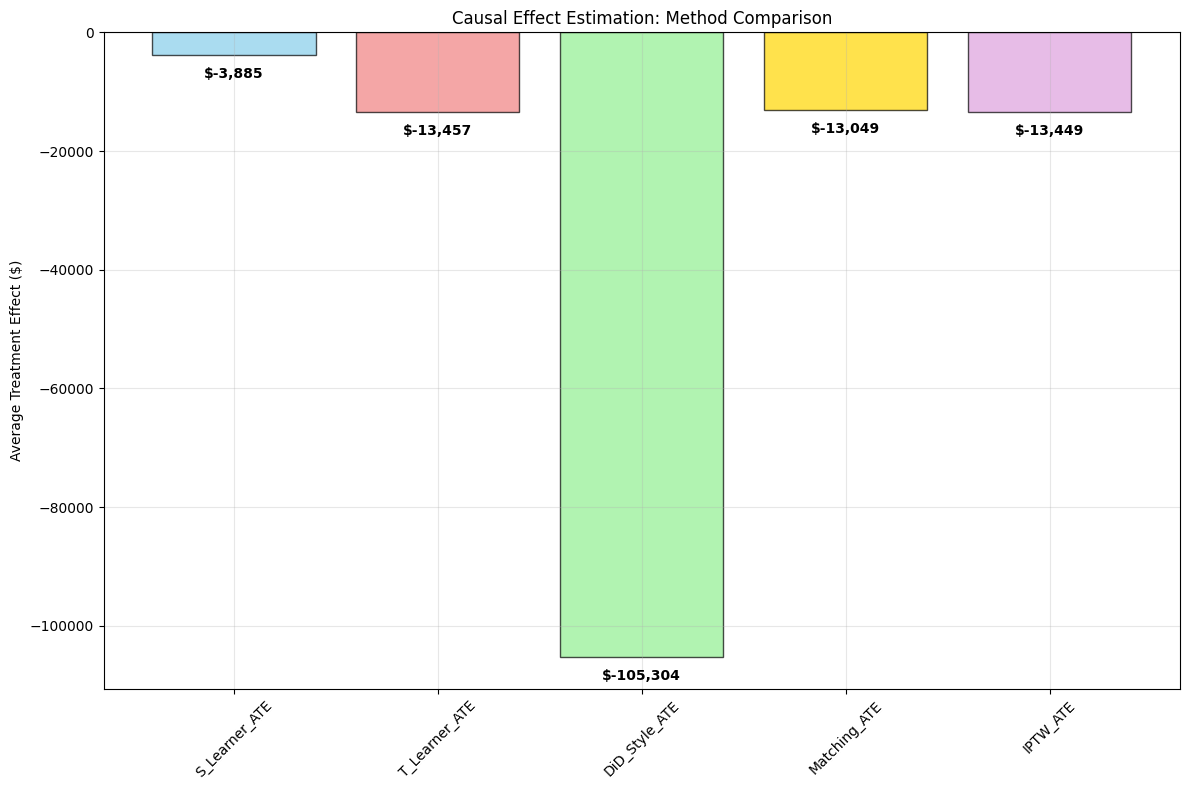

In [34]:
# 4. Simple Machine Learning Models for Causal Effect Estimationdef train_simple_ml_models(covariates, treatment, outcome):    """Train simple ML models for causal effect estimation"""    results = {}        # Split data    from sklearn.model_selection import train_test_split    X_train, X_test, t_train, t_test, y_train, y_test = train_test_split(        covariates, treatment, outcome, test_size=0.3, random_state=42    )        # 1. S-Learner (Single Learner)    s_learner = GradientBoostingRegressor(random_state=42)    X_s_train = pd.concat([X_train.reset_index(drop=True),                            t_train.reset_index(drop=True).rename('treatment')], axis=1)    s_learner.fit(X_s_train, y_train)        # Predict counterfactuals    X_test_treated = X_test.copy()    X_test_treated['treatment'] = 1    X_test_control = X_test.copy()    X_test_control['treatment'] = 0        y_pred_treated_s = s_learner.predict(X_test_treated)    y_pred_control_s = s_learner.predict(X_test_control)    s_learner_ate = np.mean(y_pred_treated_s - y_pred_control_s)        # 2. T-Learner (Two Learners)    t_learner_treated = GradientBoostingRegressor(random_state=42)    t_learner_control = GradientBoostingRegressor(random_state=42)        # Train separate models    if len(X_train[t_train == 1]) > 10 and len(X_train[t_train == 0]) > 10:  # Ensure enough data        t_learner_treated.fit(X_train[t_train == 1], y_train[t_train == 1])        t_learner_control.fit(X_train[t_train == 0], y_train[t_train == 0])                # Predict counterfactuals        y_pred_treated_t = t_learner_treated.predict(X_test)        y_pred_control_t = t_learner_control.predict(X_test)        t_learner_ate = np.mean(y_pred_treated_t - y_pred_control_t)    else:        t_learner_ate = 0        # 3. Simple Difference-in-Differences style    # Compare means before and after accounting for covariates    from sklearn.linear_model import LinearRegression        # Fit outcome model    outcome_model = LinearRegression().fit(X_train, y_train)    treatment_model = LogisticRegression(random_state=42).fit(X_train, t_train)        # Get predictions    y_pred_test = outcome_model.predict(X_test)    t_pred_test = treatment_model.predict_proba(X_test)[:, 1]        # Calculate adjusted treatment effect    residual_outcome = y_test - y_pred_test    residual_treatment = t_test - t_pred_test        if np.sum(residual_treatment**2) > 0:        did_style_ate = np.sum(residual_treatment * residual_outcome) / np.sum(residual_treatment**2)    else:        did_style_ate = 0        # 4. Simple Matching Estimator    from sklearn.neighbors import NearestNeighbors        # Match treated and control units    treated_indices = X_test[t_test == 1].index    control_indices = X_test[t_test == 0].index        if len(treated_indices) > 0 and len(control_indices) > 0:        # Find matches for treated units in control group        nn = NearestNeighbors(n_neighbors=1, metric='euclidean')        nn.fit(X_test.loc[control_indices])                distances, indices = nn.kneighbors(X_test.loc[treated_indices])        matched_controls = control_indices[indices.flatten()]                # Calculate treatment effect        treatment_effects = y_test.loc[treated_indices].values - y_test.loc[matched_controls].values        matching_ate = np.mean(treatment_effects)    else:        matching_ate = 0        results = {        'S_Learner_ATE': s_learner_ate,        'T_Learner_ATE': t_learner_ate,        'DiD_Style_ATE': did_style_ate,        'Matching_ATE': matching_ate,        'IPTW_ATE': iptw_results['ate']    }        return results# Train ML modelsml_results = train_simple_ml_models(covariates, treatment, outcome)print("Machine Learning Causal Effect Estimation:")print("=" * 60)for method, ate in ml_results.items():    print(f"{method:<20}: ${ate:>10,.2f}")# Create comparison plotplt.figure(figsize=(12, 8))methods = list(ml_results.keys())ates = list(ml_results.values())colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']bars = plt.bar(methods, ates, color=colors, alpha=0.7, edgecolor='black')# Add value labels on barsfor bar, value in zip(bars, ates):    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500 if value > 0 else bar.get_height() - 2000,             f'${value:,.0f}', ha='center', va='bottom' if value > 0 else 'top', fontweight='bold')plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)plt.ylabel('Average Treatment Effect ($)')plt.title('Causal Effect Estimation: Method Comparison')plt.xticks(rotation=45)plt.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/causal_methods_comparison.png', dpi=300, bbox_inches='tight')plt.show()